<a href="https://colab.research.google.com/github/jaehyeon0420/agent_tutorial/blob/master/rag_basic_example/rag_basic_multimodal_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 본 파일은 텍스트, 차트, 이미지, 표로 이루어진 2026년 경제 전망.pdf로 구축한 RAG 프로젝트입니다.
#### - 멀티턴, 멀티쿼리는 포함되지 않으며 답변은 '텍스트' 또는 '텍스트 + 이미지'로 출력됩니다.
#### - 문서를 인용할 수 없는 경우, 답변이 제한됩니다.
#### - 각 슬라이드 캡셔닝 이미지, XML 기반으로 생성된 LLM 분석 결과와
#### 고정 텍스트 사이즈로 청킹된 청크를 각각의 컬렉션에 저장합니다.
#### 이후, 두 가지 전처리 방식의 검색 성능을 평가 및 비교합니다.


-------------------------------------------------------------------------------------------------------------------------------

## 세부 이미지 추출

#### 추후, 답변에 이미지를 포함시키고 검색 및 답변 정확도를 올리기 위함입니다.

#### - 1. 슬라이드내에 세부 이미지들을 추출합니다.
#### - 2. 지정값보다 크기가 작은 이미지들을 삭제합니다.
#### - 3. 코랩 환경에서 재사용을 위해 파일을 압축 및 내보냅니다.

In [1]:
%%capture --no-stderr
!sudo apt install tesseract-ocr
!sudo apt install libtesseract-dev
!sudo apt-get install poppler-utils

In [2]:
%%capture --no-stderr
!pip install -U "unstructured[all-docs]" lxml pillow==9.5.0 pdf2image==1.16.3 layoutparser[layoutmodels,tesseract]==0.3.4

- 코랩 세션 다시 시작

In [5]:
import nltk

nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [6]:
import os
import base64
from IPython.display import display, HTML
from unstructured.partition.pdf import partition_pdf

In [ ]:
# 파일 경로 설정
fpath = '/content/'
fname = "2026_경제_전망.pdf"

# PDF에서 요소 추출
raw_pdf_elements = partition_pdf(
    filename=os.path.join(fpath, fname),
    extract_images_in_pdf=True, # 이미지 추출
    skip_infer_table_types=False, # False로 하면 테이블을 추출
    chunking_strategy="by_title", # 텍스트를 섹션 경계에 따라서 청킹
    max_characters=2000, # 각 청킹 별 최대 글자 수
    new_after_n_chars=2000, # 이 숫자를 넘으면 추가로 잘라라
    combine_text_under_n_chars=2000, # 이 크기 이하의 텍스트는 다른 텍스트와 결합하라
    extract_image_block_output_dir=fpath,
)

In [6]:
tables = []
texts = []

for chunk in raw_pdf_elements:
    if "CompositeElement" in str(type(chunk)):  # Check if it's a CompositeElement
        for element in chunk.metadata.orig_elements:  # Iterate through its elements
            if "Table" in str(type(element)):  # Now check for Table type
                tables.append(element)  # Append the table element
        texts.append(chunk)  # Still append the CompositeElement to texts

In [9]:
# 테이블 갯수 확인
len(tables)

16

In [15]:
# 테이블 내용 확인 결과 : 사용 가능성 0%
print(str(tables[5]))

213 BIZ / BI / Wet oH] 7] 6~9H, 2 FFX SH AY (Primaries) SH (354) 45 (13) / 51 (20) / 4 SH Get AIS DATA, AAO, SeyAPt, QSpoje | ote (43544) 210 / 206 / 19 ole Bet AIS OPAL, WejsLOF, OJAI S ag ee? BALA (Sats SAL, WES AA) ZA (45441) 20/ 25/5 ARAt BSt TH, O[YAE, GAY, AAO S


In [38]:
# 텍스트 추출 확인 결과 : 사용 가능성 0%
print(str(texts[3])[:300])

ALA O BA 13 yaaa] Be CHAPCHA EA AAAI AALS] SON SES! 2614 281 CIs} 600% al Base GDP 2.0~2.5% (3.25%) OF] OH a ~ a 0 cu TAT, (55%) 2 25-30% 214 2 2H 5x ea ~ 9 SUE 4~45% OSaO|Al AAS Hawkish oop .y ie 264 0~19] lst SAA QT AIS, (25%) ar pee ae 274 OF HSS BAL ARAL OZ 37} 3.5% AS Q| So} Dovish rnp 19 not 2


- 지정값보다 작은 이미지들을 별도 리스트에 저장합니다.

In [3]:
import os
from PIL import Image

# 이미지 디렉토리 경로
image_path = "/content/"

# 1. 조건에 맞는 모든 파일 저장할 리스트
all_files = []

# 2. 지정한 width 이하인 파일 저장할 리스트
small_width_files = []

# 3. 지정한 height 이하인 파일 저장할 리스트
small_height_files = []

# 디렉토리 내 파일 순회
for filename in os.listdir(image_path):
    # 파일명이 'figure'로 시작하고 '.jpg'로 끝나는지 확인
    if filename.startswith('figure') and filename.endswith('.jpg'):
        all_files.append(filename)  # all_files에 추가
        try:
            # 이미지 열기
            with Image.open(os.path.join(image_path, filename)) as img:
                width, height = img.size
                # width가 지정값 이하인 경우 small_width_files에 추가
                if width <= 300:
                    small_width_files.append(filename)
                # height가 지정값 이하인 경우 small_height_files에 추가
                if height <= 300:
                    small_height_files.append(filename)
        except Exception as e:
            print(f"파일 열기 실패: {filename}, 에러: {e}")

# 문자열 기준 정렬
all_files = sorted(all_files)
small_width_files = sorted(small_width_files)
small_height_files = sorted(small_height_files)
large_width_files = sorted(list(set(all_files) - set(small_width_files)))

# 결과 출력
print(f"모든 'figure*.jpg' 파일 ({len(all_files)}개):")
print(all_files)

print(f"\nwidth가 지정값 이하인 파일 ({len(small_width_files)}개):")
print(small_width_files)

print(f"\nheight가 지정값 이하인 파일 ({len(small_height_files)}개):")
print(small_height_files)

모든 'figure*.jpg' 파일 (74개):
['figure-10-11.jpg', 'figure-10-12.jpg', 'figure-11-13.jpg', 'figure-11-14.jpg', 'figure-12-15.jpg', 'figure-12-16.jpg', 'figure-13-17.jpg', 'figure-13-18.jpg', 'figure-14-19.jpg', 'figure-14-20.jpg', 'figure-15-21.jpg', 'figure-16-22.jpg', 'figure-16-23.jpg', 'figure-17-24.jpg', 'figure-21-25.jpg', 'figure-21-26.jpg', 'figure-22-27.jpg', 'figure-22-28.jpg', 'figure-23-29.jpg', 'figure-23-30.jpg', 'figure-24-31.jpg', 'figure-24-32.jpg', 'figure-25-33.jpg', 'figure-25-34.jpg', 'figure-26-35.jpg', 'figure-26-36.jpg', 'figure-27-37.jpg', 'figure-27-38.jpg', 'figure-28-39.jpg', 'figure-28-40.jpg', 'figure-29-41.jpg', 'figure-29-42.jpg', 'figure-30-43.jpg', 'figure-30-44.jpg', 'figure-31-45.jpg', 'figure-31-46.jpg', 'figure-32-47.jpg', 'figure-32-48.jpg', 'figure-33-49.jpg', 'figure-33-50.jpg', 'figure-34-51.jpg', 'figure-34-52.jpg', 'figure-35-53.jpg', 'figure-35-54.jpg', 'figure-39-55.jpg', 'figure-40-56.jpg', 'figure-40-57.jpg', 'figure-41-58.jpg', 'figure-41-5

- 지정값 이하인 이미지들이 효용 가치가 없는 파일인지 확인합니다.

In [ ]:
# 현재 디렉토리 파일 목록
small_file_path = [image_path + '/' + file_name for file_name in small_height_files] + [image_path + '/' + file_name for file_name in small_width_files]


# 이미지들을 base64로 인코딩하고 HTML로 묶기
html = "<div style='display: flex; flex-wrap: wrap;'>"
for file_name in small_file_path:
    with open(file_name, "rb") as img_file:
        b64_img = base64.b64encode(img_file.read()).decode('utf-8')
    # object-fit: contain 추가!
    html += f"""
    <div style="flex: none; max-width: 200px; margin-right: 10px; margin-bottom: 10px;">
        <img src="data:image/jpeg;base64,{b64_img}" style="width: 100%; height: auto; display: block; object-fit: contain;">
    </div>
    """
html += "</div>"

- 지정값 초과인 파일들이 효용 가치가 있는 파일인지 확인합니다.


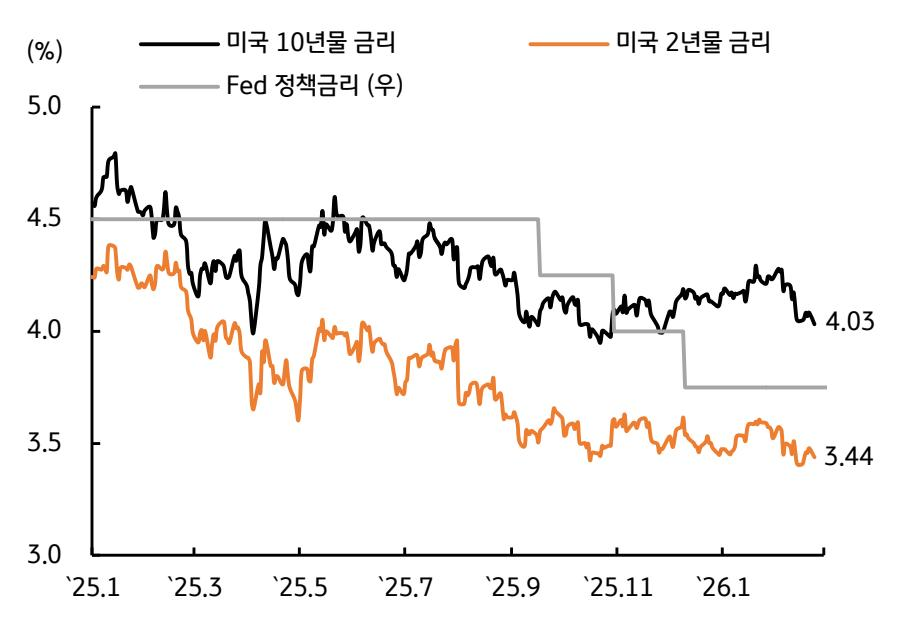
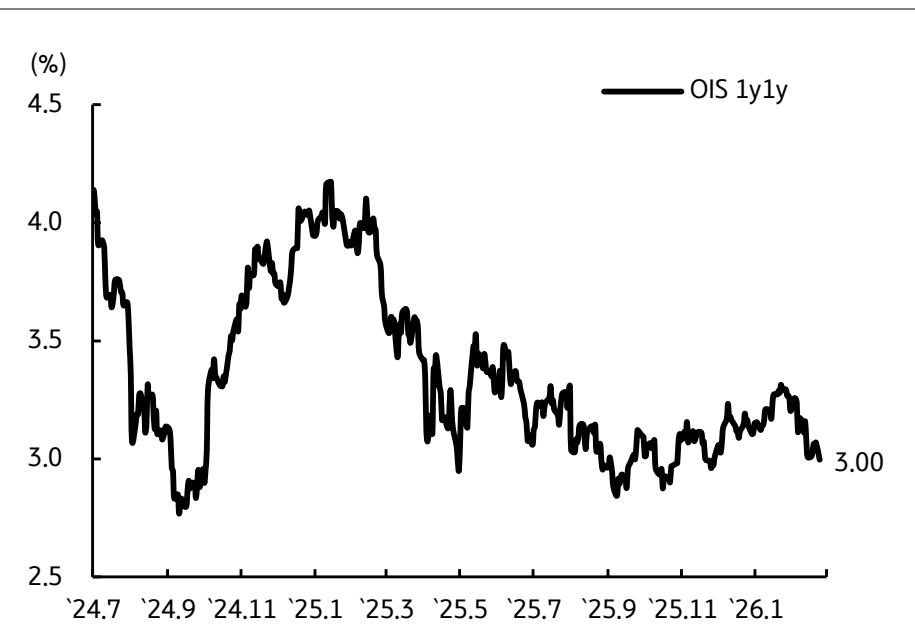
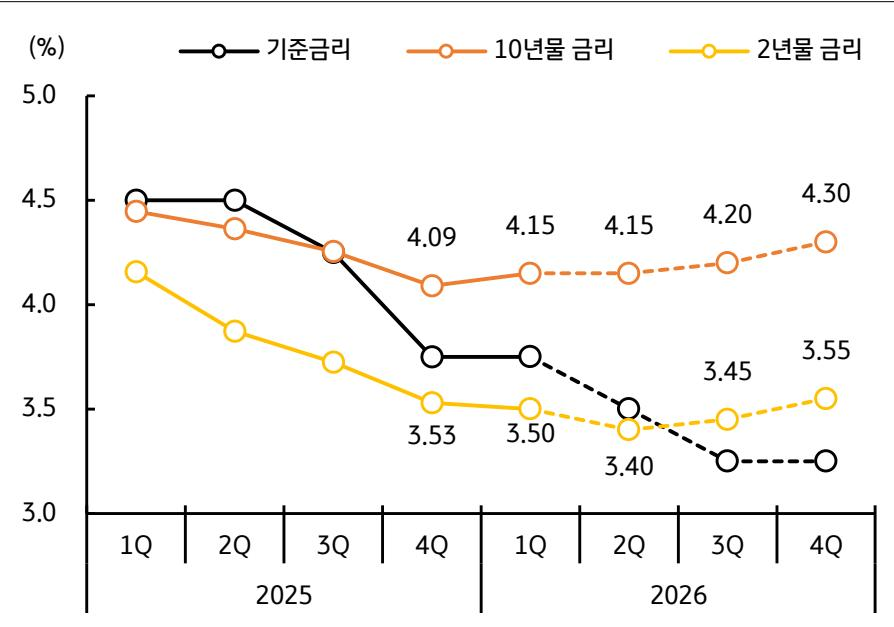
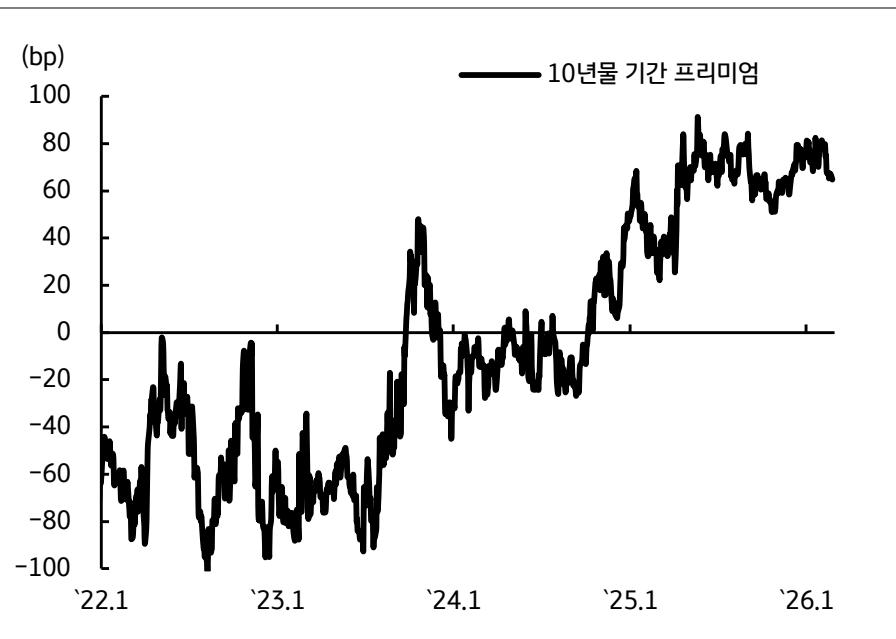
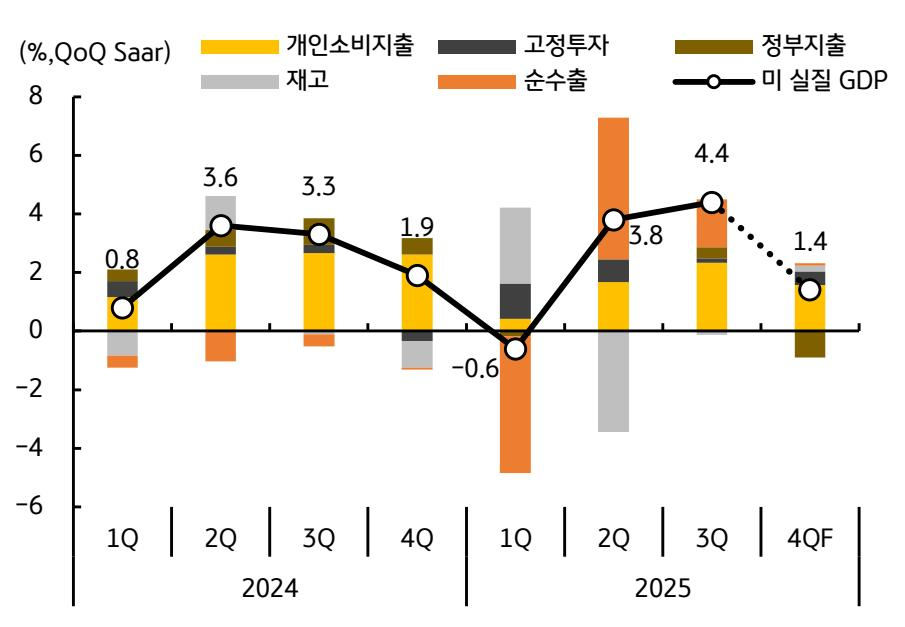
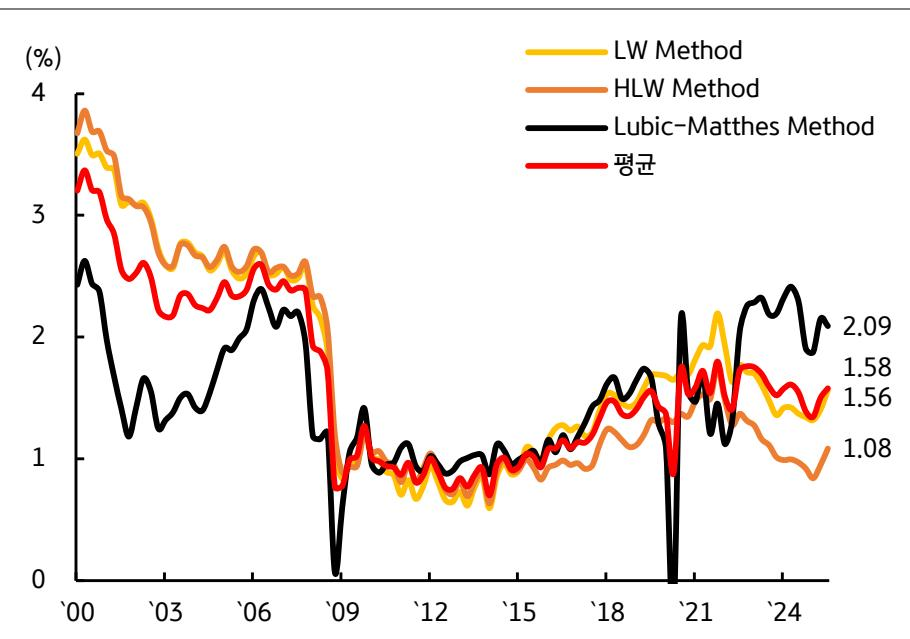
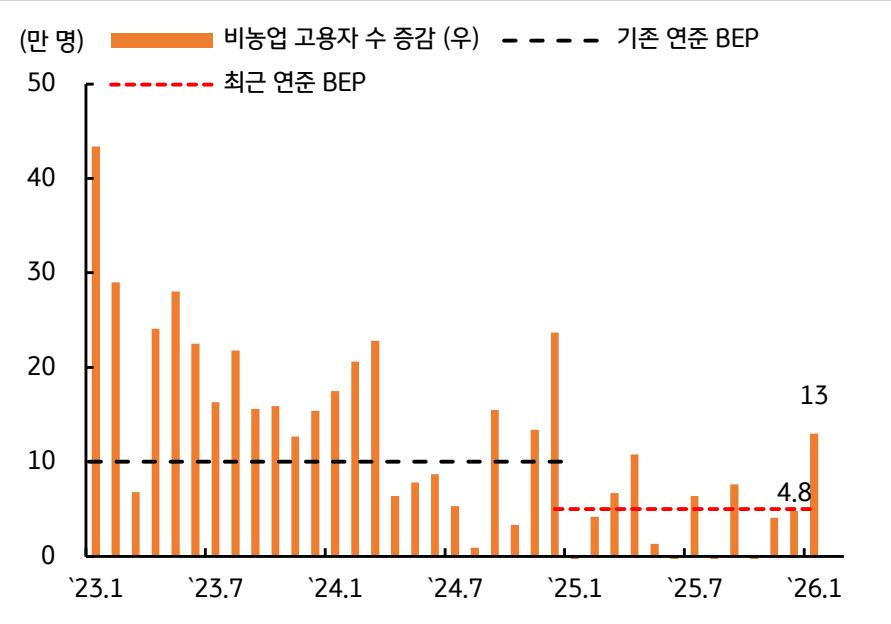
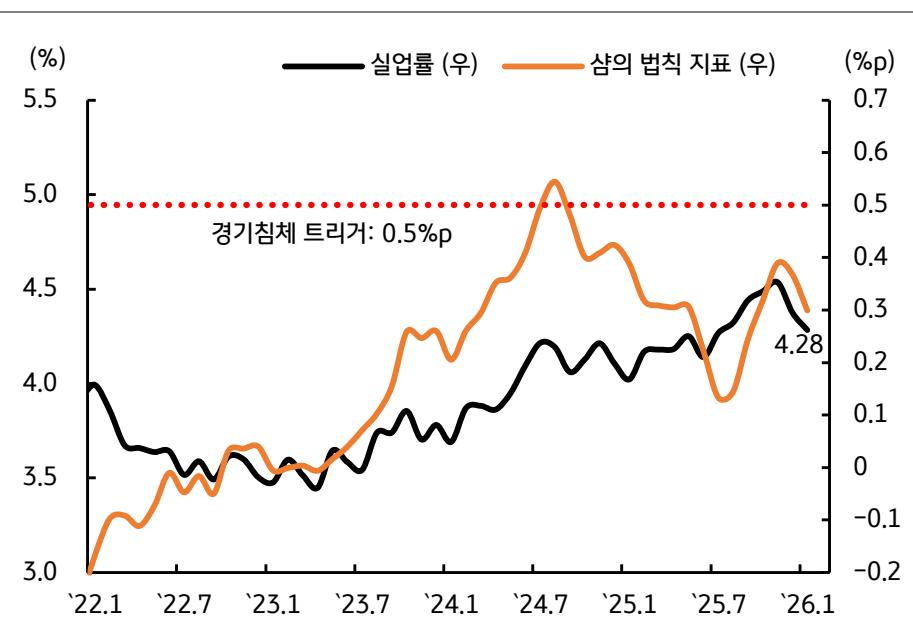
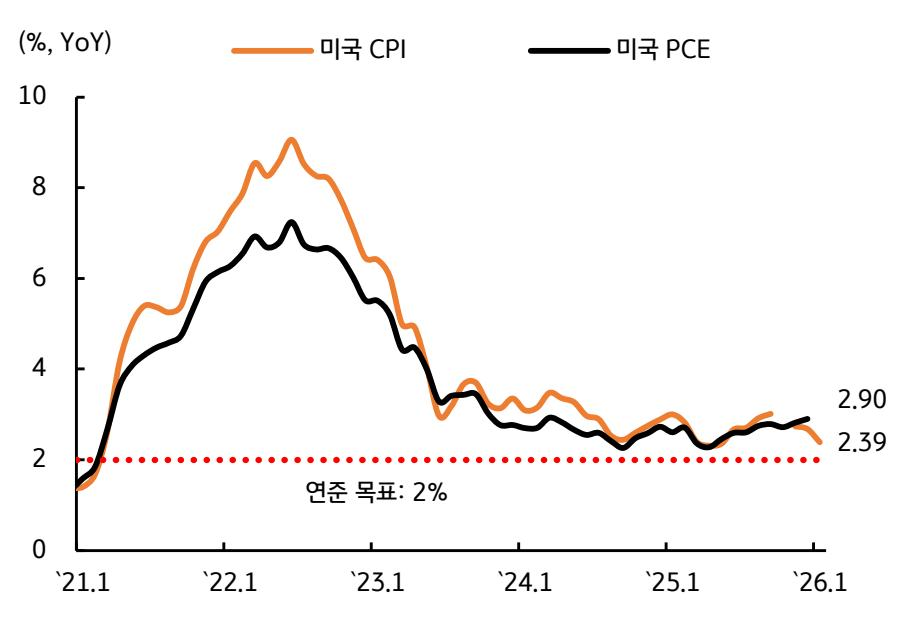
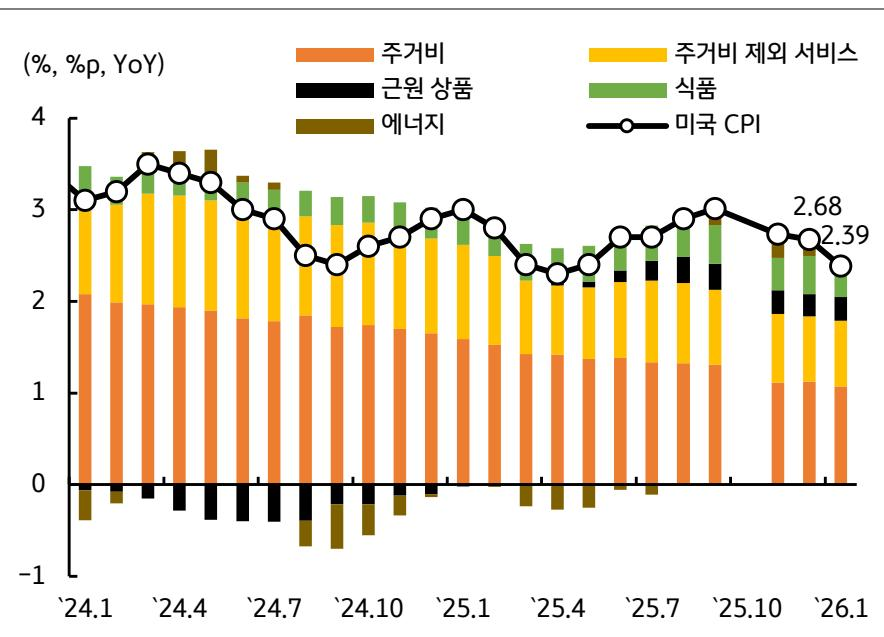
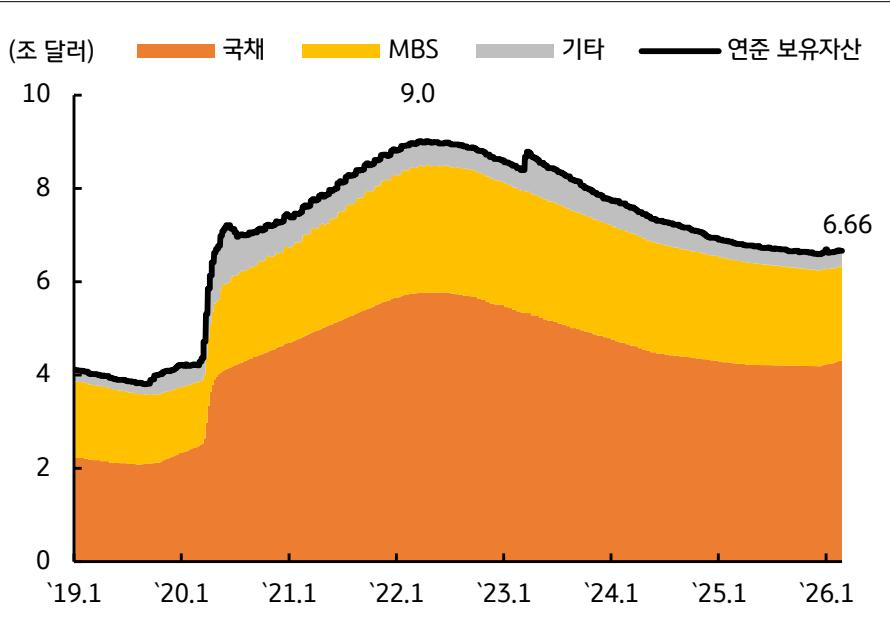
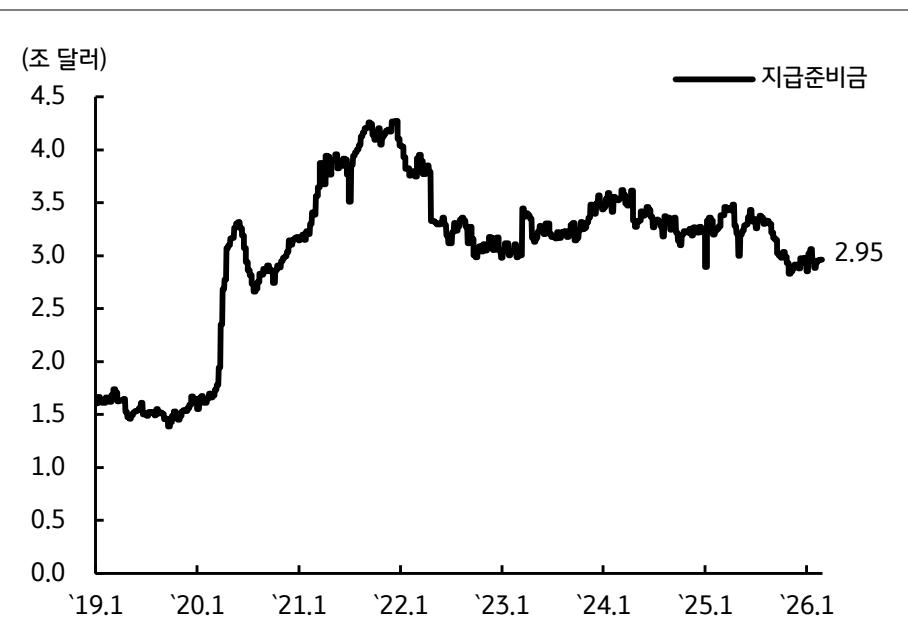
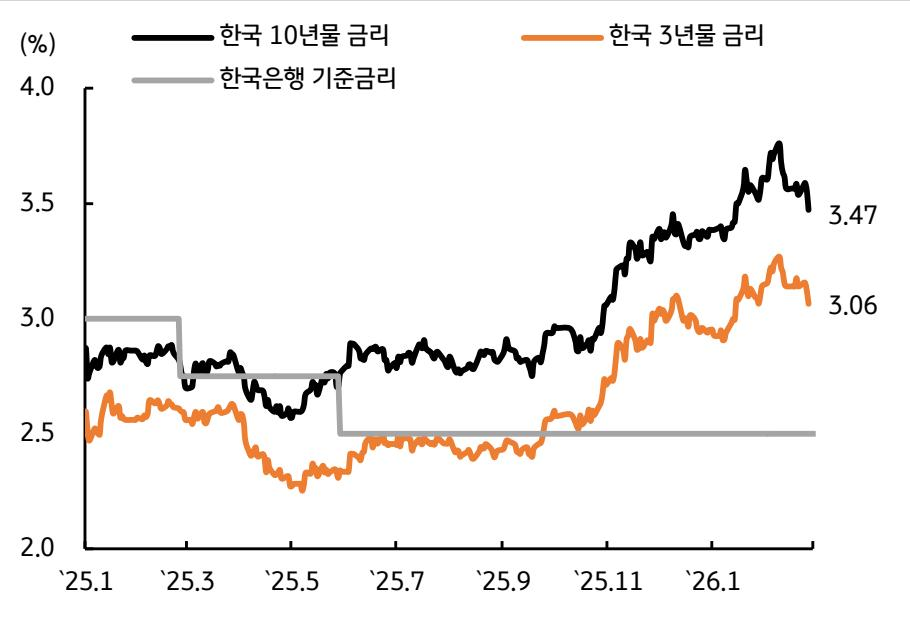
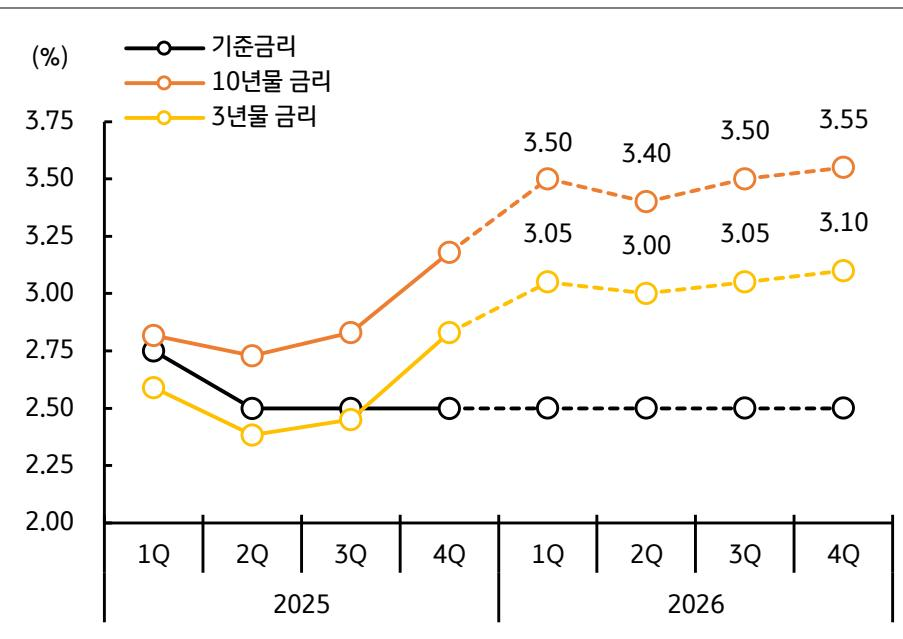
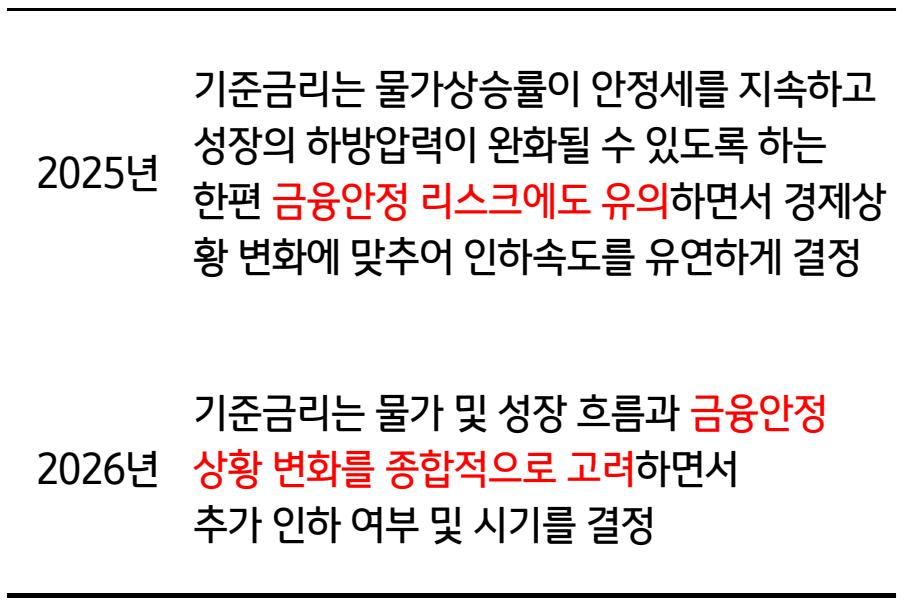
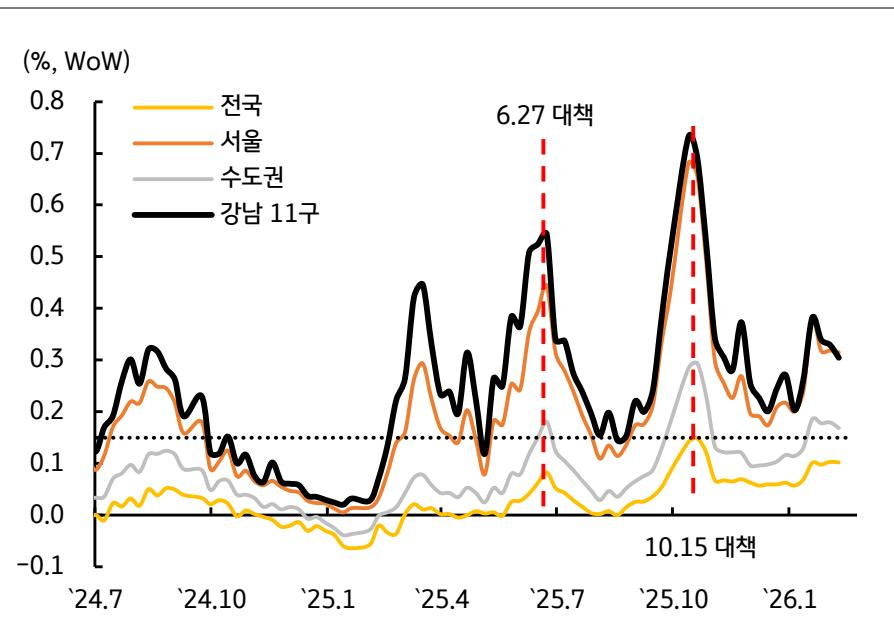
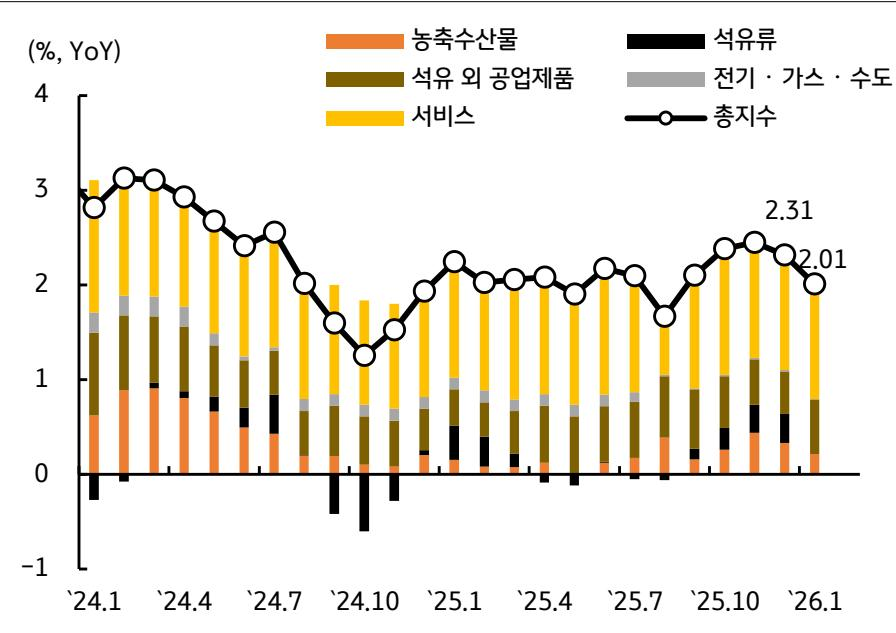
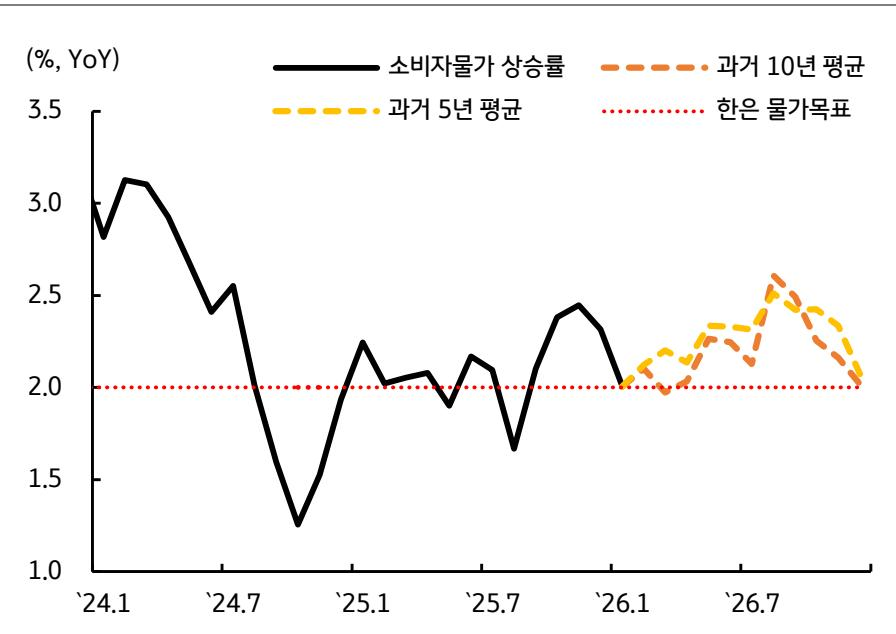

In [13]:
# 현재 디렉토리 파일 목록
file_path = [image_path + '/' + file_name for file_name in large_width_files]

# 'figure-16'로 시작하고 '.jpg'로 끝나는 파일만 선택
matched_files = [file for file in file_path if 'figure-2' in file and file.endswith('.jpg')]

# 이미지들을 base64로 인코딩하고 HTML로 묶기
html = "<div style='display: flex; flex-wrap: wrap;'>"
for file_name in matched_files:
    with open(file_name, "rb") as img_file:
        b64_img = base64.b64encode(img_file.read()).decode('utf-8')
    # object-fit: contain 추가!
    html += f"""
    <div style="flex: none; max-width: 200px; margin-right: 10px; margin-bottom: 10px;">
        <img src="data:image/jpeg;base64,{b64_img}" style="width: 100%; height: auto; display: block; object-fit: contain;">
    </div>
    """
html += "</div>"

display(HTML(html))

- 지정값 이하인 파일들을 디렉토리내에서 삭제합니다

In [ ]:
for filename in small_width_files+small_height_files:
    file_path = os.path.join(image_path, filename)
    try:
        os.remove(file_path)
        print(f"삭제 완료: {filename}")
    except Exception as e:
        print(f"삭제 실패: {filename}, 에러: {e}")

- 코랩 환경에서 파일 재사용을 위해 로컬 PC로 이미지를 내보냅니다.

In [52]:
import zipfile
import glob
import os
from google.colab import files

# 1. 설정
source_dir = '/content/'
zip_filename = 'rag_basic_multimodal_2_figure.zip'
file_pattern = 'figure*' # figure로 시작하는 파일 패턴

# 2. 대상 파일 탐색
target_files = glob.glob(os.path.join(source_dir, file_pattern))

if not target_files:
    print("압축할 파일을 찾지 못했습니다.")
else:
    # 3. 압축 파일 생성
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for file in target_files:
            zipf.write(file, os.path.basename(file))

    print(f"{len(target_files)}개의 파일을 {zip_filename}으로 압축 완료했습니다.")

    # 4. 로컬 PC로 다운로드 (선택 사항)
    files.download(zip_filename)

74개의 파일을 rag_basic_multimodal_2_figure.zip으로 압축 완료했습니다.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 전체 이미지 및 텍스트 추출

#### - 1. PDF 각 슬라이드를 이미지로 저장합니다.
#### - 2. PDF 각 슬라이드의 텍스트를 추출합니다.
#### - 3. 추출된 이미지와 텍스트를 매핑합니다.

In [14]:
!pip install pymupdf openai

- PDF 각 슬라이드를 이미지로 저장합니다.

In [56]:
import io
import fitz
from PIL import Image
import numpy as np

# 이미지를 base64 형식으로 인코딩하는 함수
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

# PNG 이미지를 최적화하는 함수
def optimize_png(img):
    img_buffer = io.BytesIO()
    img.save(img_buffer, format='PNG', optimize=True, compress_level=6)
    optimized_img = Image.open(img_buffer)
    return optimized_img

# PDF 파일을 처리하여 각 페이지를 이미지로 저장하는 함수
def process_pdf(pdf_path, output_folder, dpi=300):
    doc = fitz.open(pdf_path)
    os.makedirs(output_folder, exist_ok=True)

    for page_num in range(len(doc)):
        page = doc[page_num]
        zoom = dpi / 72
        mat = fitz.Matrix(zoom, zoom)
        pix = page.get_pixmap(matrix=mat, alpha=False)

        img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
        img_array = np.array(img)

        # 이미지 최적화 후 저장
        optimize_png(img).save(os.path.join(output_folder, f'page_{page_num+1}.png'))

    doc.close()

pdf_path = '2026_경제_전망.pdf'
output_folder = '.'
process_pdf(pdf_path, output_folder)

In [57]:
files = os.listdir()
print(files)

['.config', 'figure-34-52.jpg', 'figure-43-63.jpg', 'figure-24-31.jpg', 'figure-24-32.jpg', 'figure-17-24.jpg', 'figure-23-29.jpg', 'page_32.png', 'page_55.png', 'page_22.png', 'figure-50-73.jpg', 'page_40.png', 'page_12.png', 'page_53.png', 'figure-25-33.jpg', 'page_17.png', 'page_43.png', 'page_3.png', 'figure-53-78.jpg', 'page_52.png', 'figure-7-9.jpg', 'figure-46-66.jpg', 'figure-13-18.jpg', 'figure-31-45.jpg', 'figure-11-14.jpg', 'page_18.png', 'page_9.png', 'figure-21-26.jpg', 'figure-51-75.jpg', 'figure-32-47.jpg', 'figure-26-35.jpg', 'page_56.png', 'figure-52-77.jpg', 'rag_basic_multimodal_2_figure.zip', 'page_48.png', 'page_54.png', 'page_6.png', 'figure-22-27.jpg', 'figure-53-79.jpg', 'figure-45-65.jpg', 'page_51.png', 'figure-33-50.jpg', 'figure-27-37.jpg', 'page_10.png', 'page_16.png', 'figure-40-57.jpg', 'figure-29-42.jpg', 'page_33.png', 'page_38.png', 'page_20.png', 'page_49.png', 'page_23.png', 'figure-42-60.jpg', 'figure-14-20.jpg', 'figure-21-25.jpg', 'figure-27-38.jp

- PDF 각 슬라이드의 텍스트를 추출합니다.

In [58]:
import os
import re
import fitz  # PyMuPDF

def pdf_to_page_txts(pdf_path: str, output_dir: str = "pages") -> None:
    os.makedirs(output_dir, exist_ok=True)                # 출력 폴더 준비
    with fitz.open(pdf_path) as doc:
        total_pages = doc.page_count                      # 닫히기 전에 미리 저장
        for idx, page in enumerate(doc, start=1):
            text = page.get_text()                        # 텍스트 추출
            filename = f"page_{idx}.txt"
            filepath = os.path.join(output_dir, filename)
            with open(filepath, "w", encoding="utf-8") as f:
                f.write(text)
    print(f"{total_pages}개 페이지를 {output_dir} 폴더에 저장했습니다.")

pdf_file = '2026_경제_전망.pdf'
pdf_to_page_txts(pdf_file, ".")

56개 페이지를 . 폴더에 저장했습니다.


- 추출된 이미지와 텍스트를 매핑합니다.

In [13]:
# 디렉토리에서 매칭되는 TXT과 PNG 파일들을 가져오는 함수
def get_matched_files(directory):
    files = os.listdir(directory)

    xml_files = {}
    png_files = {}

    # TXT과 PNG 파일들을 분류
    for file in files:
        match = re.match(r'page_(\d+)\.(txt|png)$', file)
        if match:
            number = int(match.group(1))
            extension = match.group(2)
            if extension == 'txt':
                xml_files[number] = file
            elif extension == 'png':
                png_files[number] = file

    # 모든 페이지 번호를 결합하여 매칭
    all_numbers = set(xml_files.keys()).union(set(png_files.keys()))

    matched_files = []
    for number in sorted(all_numbers):
        xml_path = os.path.join(directory, xml_files[number]) if number in xml_files else 'no txt'
        png_path = os.path.join(directory, png_files[number]) if number in png_files else 'no png'
        matched_files.append((xml_path, png_path))

    return matched_files

directory = r'/content'
files = get_matched_files(directory)

files

[('/content/page_1.txt', '/content/page_1.png'),
 ('/content/page_2.txt', '/content/page_2.png'),
 ('/content/page_3.txt', '/content/page_3.png'),
 ('/content/page_4.txt', '/content/page_4.png'),
 ('/content/page_5.txt', '/content/page_5.png'),
 ('/content/page_6.txt', '/content/page_6.png'),
 ('/content/page_7.txt', '/content/page_7.png'),
 ('/content/page_8.txt', '/content/page_8.png'),
 ('/content/page_9.txt', '/content/page_9.png'),
 ('/content/page_10.txt', '/content/page_10.png'),
 ('/content/page_11.txt', '/content/page_11.png'),
 ('/content/page_12.txt', '/content/page_12.png'),
 ('/content/page_13.txt', '/content/page_13.png'),
 ('/content/page_14.txt', '/content/page_14.png'),
 ('/content/page_15.txt', '/content/page_15.png'),
 ('/content/page_16.txt', '/content/page_16.png'),
 ('/content/page_17.txt', '/content/page_17.png'),
 ('/content/page_18.txt', '/content/page_18.png'),
 ('/content/page_19.txt', '/content/page_19.png'),
 ('/content/page_20.txt', '/content/page_20.png')

## GPT 호출

#### - 1. 전체 이미지와 추출된 텍스트를 GPT에 전달하여 해석 결과를 응답 받습니다.
#### - 2. 해석 결과와 전체 이미지 정보를 매핑하여 관리합니다.

In [14]:
from tqdm import tqdm
import base64
import openai
from google.colab import userdata
import glob
from natsort import natsorted

In [15]:
os.environ["OPENAI_API_KEY"] = userdata.get('OPEN_AI_KEY')

client = openai.OpenAI()

In [22]:
# 시스템 프롬프트
system_prompt = '''당신은 경제 분석 전문가입니다.
당신이 해석할 이미지는 경제 전망 보고서입니다.

- 중요한 내용이므로 요약하지말고 문법에 신경쓰면서 보이는 그대로 작성해주세요.
- 내용을 임의로 바꾸지 마세요. 그리고 보이는 모든 내용을 다 적으십시오.
- 당신에게 당신이 해석할 파일을 txt로 변경한 내용도 드리겠습니다. 페이지 해석할 때 참고하세요.

[테이블 해석 방법]
- 테이블은 풀어서 평문 또는 나열식으로 작성해주세요. 이미지에 없는 말은 적지마세요.
- 테이블 풀어서 평문 또는 나열식으로 작성할 때 다른 행과 열이랑 헷갈리지 않게 값마다 잘 구분해서 적어주세요.
- 테이블 해석할 때 통합셀들이 존재하니 구조를 잘 해석해서 작성해주시기 바랍니다. 어떤 게 어떤 것의 하위 내용인지를 명확히 하십시오

[차트 및 그래프 해석 방법]
- 이미지 내에 차트가 여러개인 경우 좌측 차트부터 해석하십시오.
- 각 범례별 X축의 흐름에 따라 Y축 지표를 완전한 마크다운 표 형태로 작성하세요.
- 만약 차트 내용을 마크다운 표로 명확하게 변환하기 어려운 경우, 상세한 분석 보고서 형태로 작성하세요.
- 가장 중요한 건 차트의 모든 내용을 빠뜨리지 않고 모두 텍스트로 표현하는 것입니다.
'''

In [25]:
%%time
# 이미지와 txt 파일을 사용하여 AI 모델에 요청을 보내는 코드
result_lst = []

for i, file in enumerate(tqdm(files)):

    with open(file[0], 'r', encoding='utf-8') as f:
        xml_content = f.read()

    prompt = system_prompt + "\n\n[TXT 내용]\n" + xml_content

    # 세부 이미지(차트 및 그래프) 존재 여부
    pattern = os.path.join("/content/", f"figure-{(i+1)}-*")
    matching_files = glob.glob(pattern)

    add_prompt = ""

    if matching_files:
        # 파일이 존재할 경우 실행할 로직 (예: 첫 번째 매칭 파일 사용 등)
        sorted_list = natsorted(matching_files)
        prompt = prompt + f"\n\n[세부 이미지]\n- 아래에 제공되는 이미지 경로 List는 차트 갯수와 순서가 동일합니다. 답변의 차트 영역에 '출처 : [/content/figure-1-1.jpg]' 형태로 작성하세요.\n- 이미지 : {sorted_list}"

    prompt = prompt + """\n\n[주의 사항]
  - 당신의 의견은 궁금하지 않습니다. 해드렸습니다. 완성했습니다. 이런 표현도 적지마십시오. 이미지에 있는 내용만 적으십시오.
  - txt에 있는 텍스트는 반드시 해당 페이지에 존재한다는 겁니다. txt에 있는 텍스트를 빠트리지 마십시오.
  - [세부 이미지] 항목이 주어지는 경우 [출처 이미지]정보를 꼭 작성하세요. 이는 매우 중요합니다."""

    # 이미지를 base64 형식으로 인코딩
    image_path = file[1]
    base64_image = encode_image(image_path)


    response = client.chat.completions.create(
    model="gpt-4.1",
    max_tokens=2048,
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{base64_image}"}},
                {"type": "text", "text": prompt}
            ]
        }
    ]
    )

    result_lst.append(response.choices[0].message.content)


100%|██████████| 56/56 [08:08<00:00,  8.73s/it]

CPU times: user 936 ms, sys: 75.6 ms, total: 1.01 s
Wall time: 8min 8s


In [28]:
result_lst[23]

'[미국] 고용의 하방리스크 완화 – 연준의 정책금리 인하 논거 약화\n\n- 1월 고용지표, 비농업 고용자 수는 전월대비 13만 명 증가 – 고용 눈높이가 낮아진 점 고려하면 하방리스크 완화 평가 가능\n- 분기별 고용 및 임금조사(QCEW)를 반영해 25년도 비농업 고용자 수가 큰 폭 하향 조정되었으나, 시장 영향력은 제한적  \n  * 크리스토퍼 월러 이사, 1월 FOMC에서 금리인하 소수의견을 개진했으나, 고용지표 호조 지속될 시 금리동결 지지하겠다고 발언\n- 2월 계절적 이슈로 고용지표가 부진할 수 있으나, 금리 동결 기조는 파월 연준의장 퇴임 전까지 이어질 전망\n\n1월 비농업 고용, 13만 명 증가로 시장 예상 상회  \n자료: Bloomberg, KB국민은행 자본시장사업그룹\n\n---\n\n### 차트1: 1월 비농업 고용, 13만 명 증가로 시장 예상 상회\n출처: [/content/figure-24-31.jpg]\n\n| 기간    | 비농업 고용자 수 증감 (만 명) | 기존 연준 BEP (표시) | 최근 연준 BEP (표시) |\n|---------|------------------------------|---------------------|---------------------|\n| `23.1   | 약 40                        | -                   | -                   |\n| `23.7   | 약 20                        | -                   | -                   |\n| `24.1   | 약 25                        | -                   | -                   |\n| `24.7   | 약 30                        | -                   | -                   |\n| `25.1   | 약 16     

- 세부 이미지 존재하는 경우, LLM 답변에 출처(이미지 경로)가 포함되었는지 확인합니다

In [27]:
# 전체 슬라이드 순회
for i in range(len(files)):
  pattern = os.path.join("/content/", f"figure-{(i+1)}-*")
  matching_files = glob.glob(pattern)

  # 세부 이미지 존재하는 경우, LLM 답변에 출처(이미지 경로)가 포함되었는지 확인
  if matching_files:
    text_content = result_lst[i]

    check_results = {file_path: (file_path in text_content) for file_path in matching_files}

    for file_path, exists in check_results.items():
        if exists:
            print(f"✅ 포함됨: {file_path}")
            # 여기에 해당 파일이 텍스트에 있을 때 실행할 로직 추가
        else:
            print(f"❌ 미포함: {file_path}")
            # 여기에 해당 파일이 텍스트에 없을 때 실행할 로직 추가

✅ 포함됨: /content/figure-5-7.jpg
✅ 포함됨: /content/figure-7-9.jpg
✅ 포함됨: /content/figure-7-8.jpg
✅ 포함됨: /content/figure-9-10.jpg
✅ 포함됨: /content/figure-10-11.jpg
✅ 포함됨: /content/figure-10-12.jpg
✅ 포함됨: /content/figure-11-14.jpg
✅ 포함됨: /content/figure-11-13.jpg
✅ 포함됨: /content/figure-12-15.jpg
✅ 포함됨: /content/figure-12-16.jpg
✅ 포함됨: /content/figure-13-18.jpg
✅ 포함됨: /content/figure-13-17.jpg
✅ 포함됨: /content/figure-14-20.jpg
✅ 포함됨: /content/figure-14-19.jpg
✅ 포함됨: /content/figure-15-21.jpg
✅ 포함됨: /content/figure-16-22.jpg
✅ 포함됨: /content/figure-16-23.jpg
✅ 포함됨: /content/figure-17-24.jpg
✅ 포함됨: /content/figure-21-26.jpg
✅ 포함됨: /content/figure-21-25.jpg
✅ 포함됨: /content/figure-22-27.jpg
✅ 포함됨: /content/figure-22-28.jpg
✅ 포함됨: /content/figure-23-29.jpg
✅ 포함됨: /content/figure-23-30.jpg
✅ 포함됨: /content/figure-24-31.jpg
✅ 포함됨: /content/figure-24-32.jpg
✅ 포함됨: /content/figure-25-33.jpg
✅ 포함됨: /content/figure-25-34.jpg
✅ 포함됨: /content/figure-26-35.jpg
✅ 포함됨: /content/figure-26-36.jpg
✅ 포함됨: /content/f

- 페이지와 GPT 응답 결과를 비교합니다.


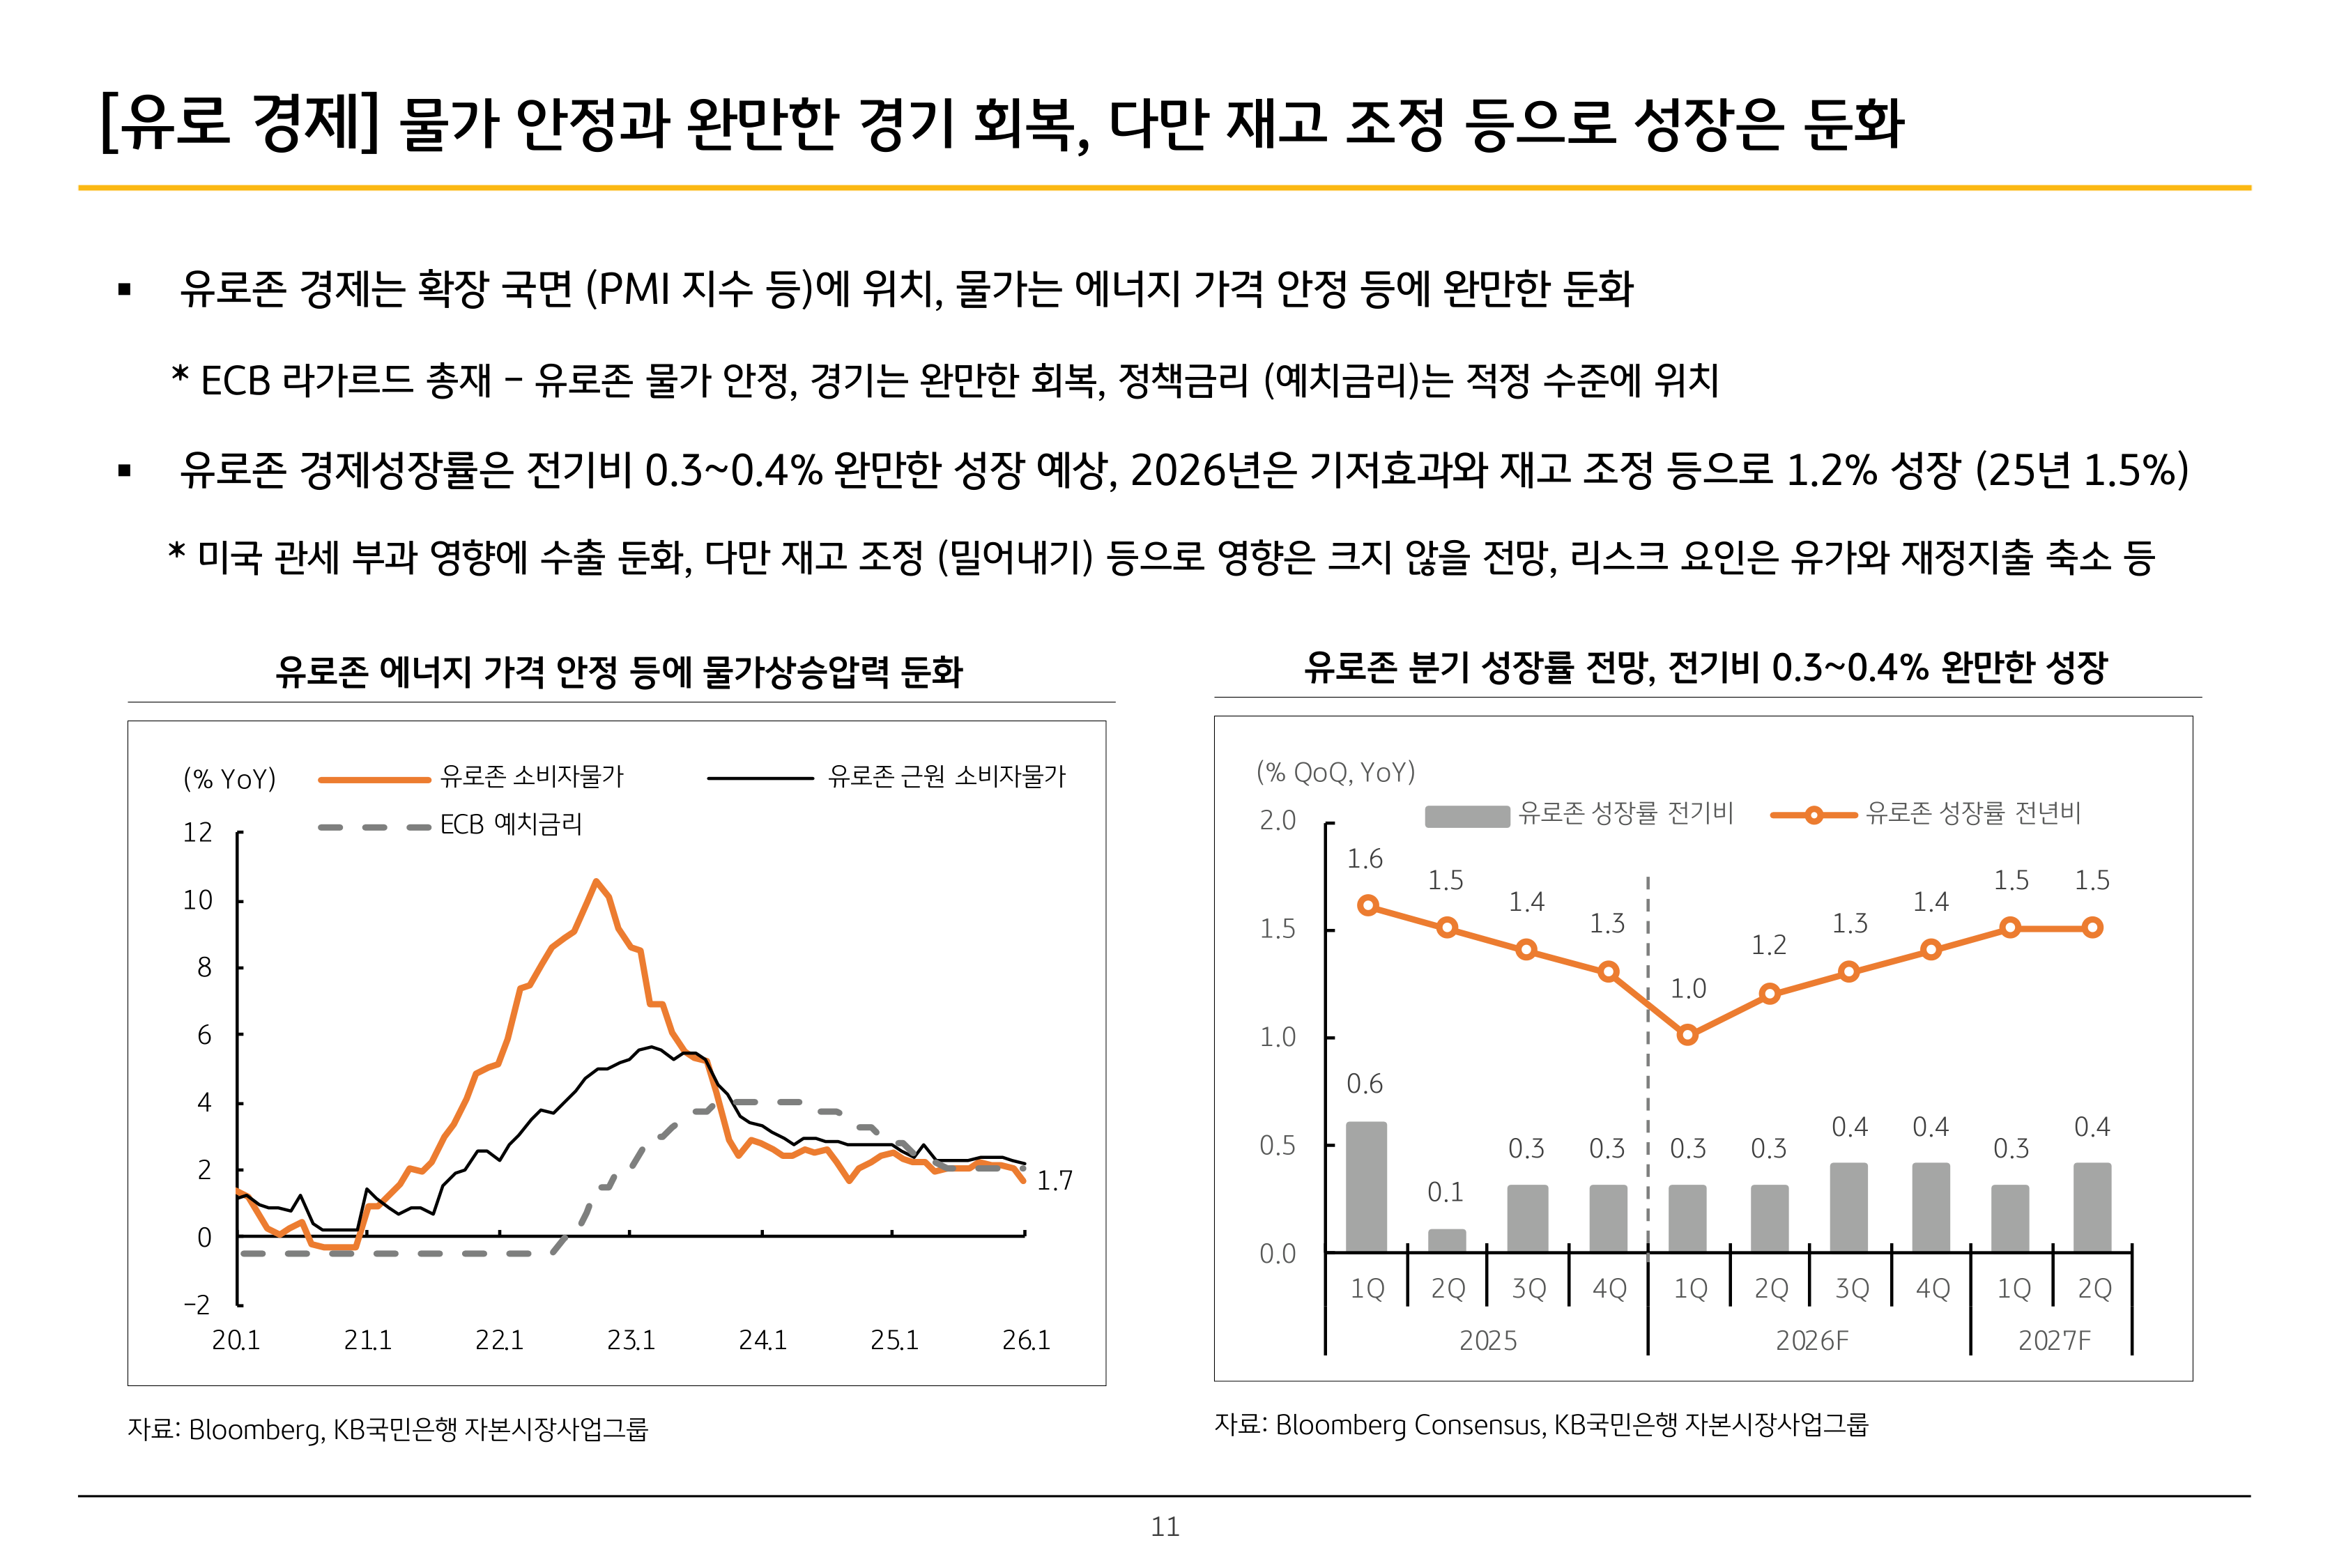

In [36]:
from IPython.display import HTML, display

# 이미지들을 base64로 인코딩하고 HTML로 묶기
file = '/content/page_11.png'

html = "<div style='display: flex; flex-wrap: wrap;'>"
with open(file, "rb") as img_file:
    b64_img = base64.b64encode(img_file.read()).decode('utf-8')
# object-fit: contain 추가!
html += f"""
<div style="flex: none; max-width: 200px; margin-right: 10px; margin-bottom: 10px;">
    <img src="data:image/jpeg;base64,{b64_img}" style="width: 200%; height: auto; display: block; object-fit: contain;">
</div>
"""
html += "</div>"

display(HTML(html))

In [29]:
print(result_lst[10])

[유로 경제] 물가 안정과 완만한 경기 회복, 다만 재고 조정 등으로 성장은 둔화

- 유로존 경제는 확장 국면(PMI 지수 등)에 위치, 물가는 에너지 가격 안정 등에 완만한 둔화  
   * ECB 라가르드 총재 – 유로존 물가 안정, 경기는 완만한 회복, 정책금리(예치금리)는 적정 수준에 위치
- 유로존 경제성장률은 전기비 0.3~0.4% 완만한 성장 예상, 2026년은 기저효과와 재고 조정 등으로 1.2% 성장(25년 1.5%)  
   * 미국 관세 부과 영향에 수출 둔화, 다만 재고 조정(밀어내기) 등으로 영향은 크지 않을 전망, 리스크 요인은 유가와 재정지출 축소 등

---

### 유로존 에너지 가격 안정 등에 물가상승압력 둔화  
자료: Bloomberg, KB국민은행 자본시장사업그룹  
출처 : [/content/figure-11-13.jpg]

#### 차트 범례 및 X/Y축 데이터
- X축: 연도 및 월(20.1, 21.1, 22.1, 23.1, 24.1, 25.1, 26.1)
- Y축: % YoY (연간 증가율, -2 ~ 12까지 표시)

| 연도/월 | 유로존 소비자물가 | 유로존 근원 소비자물가 | ECB 예치금리 |
|---------|--------------------|-------------------------|--------------|
| 20.1    | 약 1               | 약 1                    | 약 -0.5      |
| 21.1    | 약 0.5             | 약 1                    | 약 -0.5      |
| 22.1    | 약 4               | 약 2.5                  | 약 -0.5      |
| 23.1    | 약 8.5             | 약 5.5                  | 약 2.5       |
| 24.1    | 약 2.5             | 약 3             

## RAG

#### - LLM 답변을 임베딩하여 벡터 DB에 저장합니다.
#### - 2026_경제_전망.pdf 파일 내 각 슬라이드는 모두 독립적이므로 별도 overlap 하거나, Q&A 형태의 합성 데이터는 제작하지 않습니다.

In [32]:
pip install -U chromadb

In [33]:
import chromadb
from openai import OpenAI
from chromadb.utils import embedding_functions
from google.colab import userdata

In [34]:
documents_content = []
metadatas = []
ids = []

for i, (f, r) in enumerate(zip(files, result_lst)):
    page_name = f[1].split('/')[-1] # 파일명만 추출 (예: page_1.png)

    # ChromaDB에 직접 넣을 데이터들
    documents_content.append(r) # 실제 분석 텍스트
    metadatas.append({"source": page_name, "orign_txt": f[0]}) # 메타데이터
    ids.append(f"id_{i}") # 고유 ID (필수)

In [35]:
openai_ef = embedding_functions.OpenAIEmbeddingFunction(
    api_key=userdata.get('OPEN_AI_KEY'),
    model_name="text-embedding-3-large"
)

# ChromaDB 클라이언트 및 컬렉션 설정
client_1 = chromadb.PersistentClient(path="./chroma_db")
processed_collection = client_1.get_or_create_collection(
    name="processed_collection",
    embedding_function=openai_ef
)

# 데이터 적재 (중요: documents는 반드시 문자열 리스트여야 함)
processed_collection.add(
    ids=ids,
    documents=documents_content,
    metadatas=metadatas
)

open_ai_client = OpenAI(api_key=userdata.get('OPEN_AI_KEY'))

print(f"적재 완료: 총 {processed_collection.count()}개의 페이지가 저장되었습니다.")

적재 완료: 총 56개의 페이지가 저장되었습니다.


In [61]:
import re
import os
import base64
from IPython.display import display, Markdown

# 벡터 DB에서 검색된 문서들을 병합하는 함수
def context_pair(all_results) :
    context_parts = []
    for i, doc in enumerate(all_results):
        source = doc['metadata'].get('source', '알 수 없음')
        # 컨텍스트에 메타데이터를 포함시켜 LLM이 인용할 수 있게 함
        context_parts.append(f"[문서 {i+1}]\n{doc['page_content']}")

    return  "\n\n".join(context_parts)

# 검색 문서 기반 LLM 답변 요청 함수
def get_llm_response(context: str, query: str) :

    system_prompt = """당신은 경제 전망에 대해 설명해주는 챗봇 '머니'입니다.

    1. 당신은 오직 위에서 제공된 참고 자료에 있는 사실 정보에만 근거해 사용자 질문에 답변해야 하며, 절대 지어내거나 허구의 정보를 포함해서는 안 됩니다.
    2. 만약 사용자의 질문을 명확히 하는 것이 답변에 도움이 된다면, 질문을 시도할 수 있습니다.
    3. 만약 참고 자료에 있는 정보로 질문에 충분히 답변할 수 없다면, 다음의 문장을 그대로 답변으로 사용해야 합니다: "죄송합니다. 참고 자료에는 요청하신 질문에 답변할 만한 충분한 정보가 없네요.".
    4. 반드시 한국어로 1인칭 시점에서 정확하고 엄격한 스타일로 답변해야 하며, 사실을 기반으로 상세히 설명해야 합니다.
    5. 만약 질문과 연관된 참고 정보 중, 출처 정보가 있다면 반드시 '출처 : [/content/figure-10-11.jpg]' 형식으로 답변 중간에 자연스럽게 포함하며 설명하세요. 이는 매우 중요합니다.
    """

    user_prompt = f"""
    ## 참고 정보
    {context}

    ## 사용자 질문
    {query}

    ## 답변:"""

    response = open_ai_client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt}
                ],
                temperature=0
            )

    return response.choices[0].message.content.strip()

# 출처 정보 img 태그로 변환
def convert_source_to_img_tag(text: str) -> str:
    """
    텍스트 내 '출처: [/content/파일명.jpg]' 패턴을
    <img src="/content/파일명.jpg"> 태그로 변환합니다.
    """
    # 정규표현식 패턴 설명:
    # 출처\s*:\s* : '출처' 문자열 뒤에 공백이 있을 수도 없을 수도 있는 콜론(:)
    # \[(/content/.*?\.(?:jpg|png|jpeg))\] : [/content/...] 형태 안의 경로 추출
    pattern = r'출처\s*:\s*\[\s*(/content/.*?\.(?:jpg|png|jpeg))\s*\]'

    # re.sub를 사용하여 매칭된 그룹(경로)을 img 태그에 삽입
    # \1은 첫 번째 괄호 그룹인 파일 경로를 의미합니다.
    result = re.sub(pattern, r'<img src="\1">', text)

    return result

# LLM 답변 텍스트 내 img 태그 화면에 출력
def process_and_display_content(text, img_width=500):

    # 1. <img> 태그 존재 여부 확인용 패턴
    img_tag_pattern = re.compile(r'<img\s+src="([^"]+)"[^>]*>')

    # 텍스트 내에 <img> 태그가 아예 없다면 일반 마크다운으로 출력 후 종료
    if not img_tag_pattern.search(text):
        display(Markdown(text))
        return

    # 2. 이미지 경로를 base64 데이터로 교체하는 내부 함수
    def replace_with_base64(match):
        img_path = match.group(1)

        # 경로 정규화 (절대 경로 보장)
        full_path = img_path if img_path.startswith('/content/') else f'/content/{img_path}'

        if not os.path.exists(full_path):
            print(f"⚠️ 경고: 파일을 찾을 수 없습니다 -> {full_path}")
            return f"<b>[이미지 누락: {os.path.basename(full_path)}]</b>"

        try:
            with open(full_path, "rb") as f:
                ext = full_path.split('.')[-1].lower()
                mime_type = "image/png" if ext == "png" else "image/jpeg"
                b64_img = base64.b64encode(f.read()).decode('utf-8')

            # 너비(width)가 적용된 HTML 이미지 태그 반환
            return f'<img src="data:{mime_type};base64,{b64_img}" width="{img_width}">'
        except Exception as e:
            print(f"❌ 변환 오류 ({full_path}): {e}")
            return match.group(0)

    # 3. 모든 이미지 태그 변환 실행
    final_md = img_tag_pattern.sub(replace_with_base64, text)

    # 4. 최종 마크다운 출력
    display(Markdown(final_md))



# 검색 시, 외부 호출 함수
def retrieve(query: str, num_docs: int = 5) -> list[dict]:
    all_results = []
    seen_contents = set()

    # 쿼리 임베딩
    query_vector = openai_ef.embed_query(query)[0]

    # ChromaDB 검색
    search_results = processed_collection.query(
        query_embeddings=[query_vector],
        n_results=num_docs
    )

    # 결과 파싱 및 중복 제거
    for i in range(len(search_results['documents'][0])):
        content = search_results['documents'][0][i]
        metadata = search_results['metadatas'][0][i] or {}

        # 중복 검사 및 결과 병합
        if content not in seen_contents:
            seen_contents.add(content)
            # 메타데이터에 어떤 쿼리로 검색되었는지 기록 (디버깅용)
            metadata["source_query"] = query

            all_results.append({
                "page_content": content,
                "metadata": metadata
            })

    # 검색된 문서들을 하나의 문자열로 병합
    context = context_pair(all_results)
    # LLM 답변 요청
    res_msg = get_llm_response(context, query)
    # LLM 답변 내 출처 정보 HTML로 변경
    final_result = convert_source_to_img_tag(res_msg)

    return process_and_display_content(final_result)

2026년 미국 금리 전망에 따르면, 예상보다 견조한 미국 경제 상황을 고려하여 금리 인하 시점이 지연될 것으로 보입니다. 특히, 민간소비가 호조를 보이고 있어 연준의 금리 인하가 점진적으로 진행될 것으로 예상됩니다. 연준은 과잉완화로 인한 인플레이션 우려 때문에 정책금리를 중립금리 이하로 내리기 어려운 입장입니다.

2026년 1분기에는 기준금리가 4.30%에 도달할 것으로 보이며, 2분기와 3분기에는 각각 25bp씩 인하하여 최종금리는 3.25%에 도달할 전망입니다. 그러나 시장금리는 연준의 금리 인하 사이클이 진행 중인 점을 반영해 완만한 하락을 예상하나, 인하 기대가 과도하다는 점을 반영해 하락 폭은 제한적일 것으로 보입니다. 하반기 이후에는 인플레이션 압력으로 금리 인하 사이클 종료 인식이 확산되면서 시장금리가 반등할 것으로 예상됩니다.

또한, 10년물 국채 금리는 2026년 1분기 4.15%에서 4분기에는 4.30%로 상승할 것으로 보이며, 2년물 금리는 3.45%에서 3.55%로 상승할 것으로 예상됩니다. 이러한 전망은 미국 경제의 성장률과 고용지표가 양호한 흐름을 이어가고 있다는 점에서 기인합니다. 

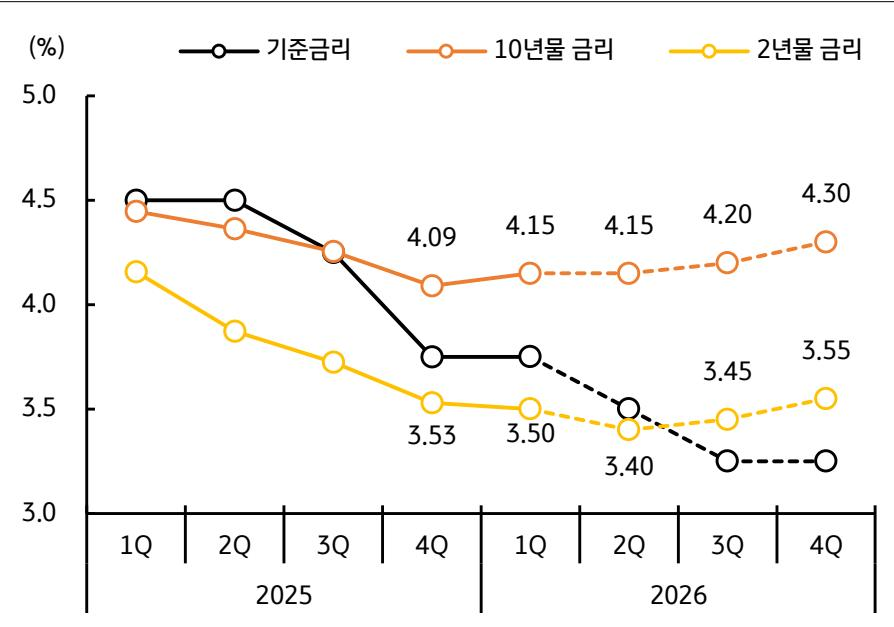

In [62]:
res_msg = retrieve(query="2026년 미국 금리전망 어때?")

res_msg

미국 주요 기술 기업의 자본지출 계획은 계속해서 확장되고 있습니다. 특히 Amazon, Google, Microsoft, Meta와 같은 기업들이 2025년까지 총 3,700억 달러(약 $370B)의 자본지출을 계획하고 있습니다. 이러한 자본지출은 플랫폼 선점 및 기술 선점을 위한 것으로, 과잉 투자에 대한 우려도 존재합니다. 

또한, AI 민간 투자에 대한 요구 수익은 6,500억 달러(약 $650B)에 달하지만, 여전히 수익성에 대한 의문이 제기되고 있습니다. 이러한 상황은 AI 투자에 대한 기대와 함께, 과잉 경쟁 심화로 인한 주가 조정 가능성도 내포하고 있습니다. 특히 한국의 반도체 사이클 역시 글로벌 AI 투자에 따른 기대가 반영되고 있으며, AI 투자 위축 시 반도체 업황 조정이 심화될 우려가 있습니다. 

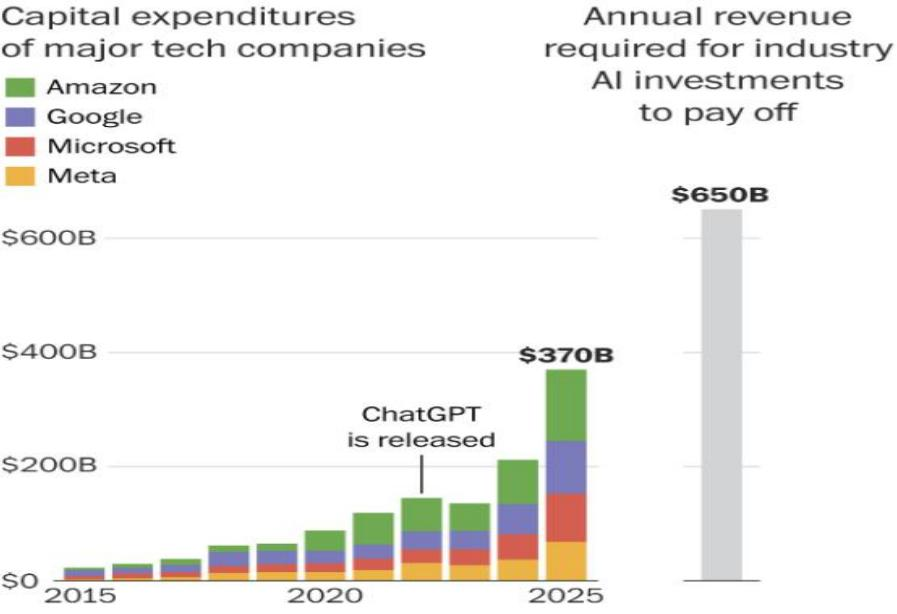

In [63]:
res_msg = retrieve(query="미국 주요 기술 기업 자본지출 계획 알려줘")

res_msg

일본 경제성장률은 2025년과 2026년 동안 각각 1% 내외로 안정세를 보일 것으로 전망됩니다. 구체적으로, 2025년 4분기에는 0.1%의 성장률을 기록할 것으로 예상되며, 2026년 1분기에는 0.6%, 2분기에는 0.3%, 3분기에는 1.0%, 4분기에는 1.4%로 증가할 것으로 보입니다. 이러한 성장률은 일본 정부의 재정지출 확대와 소비세 감면 등의 정책에도 불구하고 순수출의 약화로 인해 둔화될 가능성이 있습니다. 

또한, 일본의 물가는 2%를 상회하며, 임금 상승 등의 요인으로 인해 일본은행(BOJ)은 2026년 2분기와 4분기에 각각 금리 인상을 단행할 것으로 예상됩니다. 최종적으로 금리는 1.50%에 이를 것으로 보입니다. 이러한 경제적 배경 속에서 일본의 경제성장률은 1% 수준으로 수렴할 것으로 전망됩니다. 

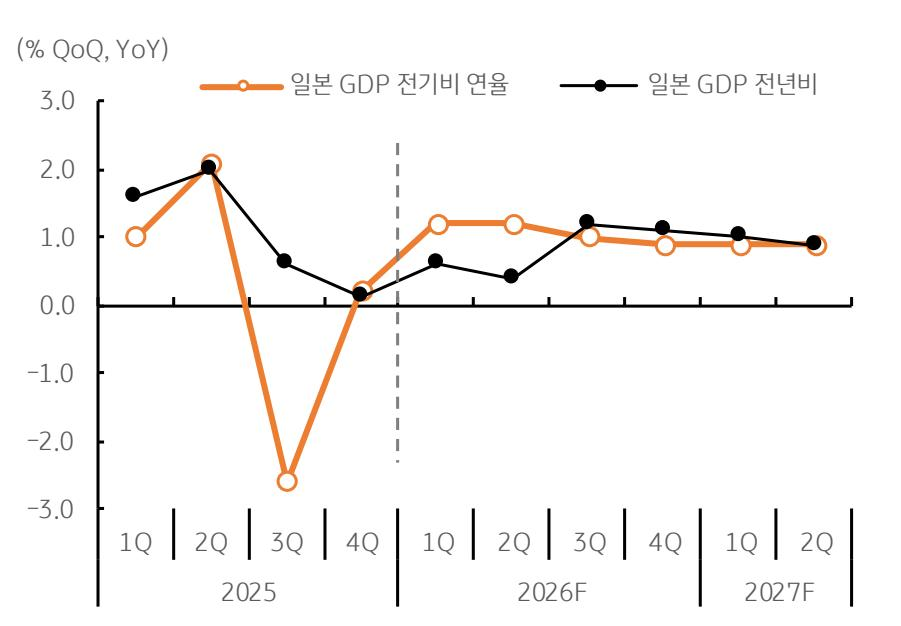

In [64]:
res_msg = retrieve(query="일본 경제성장률 전망")

res_msg

## 검색 성능 평가

### 위 전처리된 문서와 전처리 이전의 문서 검색 성능을 비교하기 위해, 원본 문서 텍스트를 size 기준으로 청킹합니다.

In [65]:
import os
import json
from typing import List, Dict

# OpenAI API 관련
from openai import OpenAI

# 벡터 DB 관련
import chromadb
from chromadb.utils import embedding_functions

# PDF 로딩 관련
from pypdf import PdfReader

- PDF 모든 텍스트를 병합합니다.

In [66]:
def load_pdf(file_path: str) -> str:
    reader = PdfReader(file_path)
    full_text = ""

    for page in reader.pages:
        # 페이지 텍스트 추출 (None 반환 대비)
        text = page.extract_text()
        if text:
            full_text += text + "\n"

    return full_text

pdf_text = load_pdf("2026_경제_전망.pdf")

- 텍스트를 오버랩 기준으로 청킹하여 문자열 리스트를 생성합니다.

In [67]:
def chunk_text(text: str, chunk_size: int, chunk_overlap: int) -> List[str]:
    chunks = []

    # 시작 지점을 overlap만큼 이동하며 반복
    start = 0

    while start < len(text):
        # 종료 지점 계산
        end = start + chunk_size

        # 청킹
        chunk = text[start:end]
        chunks.append(chunk)

        # 다음 시작 지점 = 현재 종료 지점 - 오버랩
        start += (chunk_size - chunk_overlap)

        # 무한 루프 방지 (오버랩이 청크 사이즈보다 크거나 같을 경우)
        if chunk_size <= chunk_overlap:
            break

    return chunks

# 설정 값 예시
CHUNK_SIZE = 500
CHUNK_OVERLAP = 100

chunks = chunk_text(pdf_text, CHUNK_SIZE, CHUNK_OVERLAP)

In [68]:
import uuid
from google.colab import userdata

openai_ef = embedding_functions.OpenAIEmbeddingFunction(
    api_key=userdata.get('OPEN_AI_KEY'),
    model_name="text-embedding-3-large"
)

client_2 = chromadb.PersistentClient(path="./chroma_db")
none_processed_collection = client_2.get_or_create_collection(
    name="none_processed_collection",
    embedding_function=openai_ef
)


In [69]:
def add_chunks_to_db(chunks: list[str], metadata_list: list[dict] = None):
    """
    동일한 청크를 OpenAI와 BGE-M3 모델로 각각 임베딩하여 별도 컬렉션에 적재합니다.
    """

    # 동일한 청크는 두 DB에서 같은 ID를 가지게 하여 추후 비교 평가를 용이하게 합니다.
    ids = [str(uuid.uuid4()) for _ in range(len(chunks))]
    if metadata_list is None:
        metadata_list = [{"source": "pdf_document"} for _ in range(len(chunks))]

    none_processed_collection.add(
        ids=ids,
        documents=chunks,
        metadatas=metadata_list
    )

    print(f"\n[성공] 총 {len(chunks)}개의 청크가 벡터 DB에 저장되었습니다.")

In [70]:
add_chunks_to_db(chunks)


[성공] 총 101개의 청크가 벡터 DB에 저장되었습니다.


- 평가를 위해, 각 문서별로 질문을 2개씩 생성합니다.

In [71]:
import os
import re
import time
from tqdm import tqdm
from openai import OpenAI

open_ai_client = OpenAI(api_key=userdata.get('OPEN_AI_KEY'))

def generate_evaluation_dataset(chunks, num_questions_per_doc=2):
    """
    각 청크(Chunk)에 대한 질문을 생성하고 평가용 데이터셋 구조를 반환합니다.

    Args:
        chunks: 청크 리스트
        num_questions_per_doc: 청크 당 생성할 질문 수

    Returns:
        all_queries: {질문_ID: 질문_텍스트}
        corpus: {문서_ID: 문서_텍스트}
        relevant_docs: {질문_ID: [관련_문서_ID]}
    """

    all_queries = {}
    corpus = {}
    relevant_docs = {}

    prompt_template = """
    당신은 질문 생성 전문가입니다. 아래 제공된 [맥락]을 읽고, 해당 내용에 대해 답할 수 있는 질문을 {num}개 생성하세요.

    [맥락]
    {context}

    [지침]
    - 질문은 반드시 한국어로 작성하세요.
    - 각 질문은 독립적이어야 하며, 본문 없이 질문만 읽어도 의미가 전달되어야 합니다.
    - '위 본문에 따르면', '제시된 글에서'와 같은 표현은 절대 사용하지 마세요.
    - 질문만 작성하고 답안이나 해설은 포함하지 마세요.
    - 아래 형식과 같이 번호를 나열하여 생성하세요:
    1. 질문 내용
    2. 질문 내용
    """

    for i, chunk in enumerate(tqdm(chunks, desc="질문 생성 중")):
        time.sleep(1.0)

        # 입력 형식이 문자열인지 딕셔너리인지 확인하여 처리
        if isinstance(chunk, dict):
            text = chunk.get('text', '')
            doc_id = chunk.get('id', f"doc_{i}")
        else:
            text = chunk
            doc_id = f"doc_{i}"

        corpus[doc_id] = text

        try:
            # LLM 호출 (온도는 0으로 설정하여 일관성 유지)
            response = open_ai_client.chat.completions.create(
                model="gpt-4o",
                messages=[
                    {"role": "system", "content": "당신은 질문 생성 도우미입니다. 제공된 정보 기반으로 질문을 생성하세요."},
                    {"role": "user", "content": prompt_template.format(context=text, num=num_questions_per_doc)}
                ],
                temperature=0.7
            )

            # 응답 텍스트 파싱
            raw_output = response.choices[0].message.content.strip()
            lines = raw_output.split("\n")

            q_count = 0
            for line in lines:
                # 숫자. 형식을 제거하고 실제 질문 텍스트만 추출
                clean_question = re.sub(r"^\d+[\.\)\s]+", "", line).strip()

                if clean_question and len(clean_question) > 5:
                    query_id = f"q_{doc_id}_{q_count}"
                    all_queries[query_id] = clean_question
                    relevant_docs[query_id] = [doc_id]
                    q_count += 1

                    if q_count >= num_questions_per_doc:
                        break

        except Exception as e:
            print(f"\n[오류] 문서 {doc_id} 처리 중 오류 발생: {e}")

    return all_queries, corpus, relevant_docs

- queries : 'q_문서번호_질문번호'를 key로, '생성된 질문'을 value로 가지는 딕셔너리
- corpus : 'doc_문서번호'를 key로, 문서를 value로 가지는 딕셔너리
- relevant_docs : 'q_문서번호_질문번호'를 key로, 'doc_문서번호'를 value로 가지는 딕셔너리

In [72]:
n_queries, n_corpus, n_relevant_docs = generate_evaluation_dataset(chunks)

질문 생성 중: 100%|██████████| 101/101 [03:35<00:00,  2.14s/it]


In [73]:
p_queries, p_corpus, p_relevant_docs = generate_evaluation_dataset(documents_content)

질문 생성 중: 100%|██████████| 56/56 [02:05<00:00,  2.24s/it]


In [74]:
from typing import Any, Optional

#  리트리버 Wrapper
class Retriever:
    """
    이미 구축된 ChromaDB 컬렉션을 사용하여 벡터 검색을 수행하는 클래스입니다.
    """
    def __init__(self, collection, client, model_name="text-embedding-3-large", k: int = 5):
        self.collection = collection
        self.client = client
        self.model_name = model_name
        self.k = k

    def invoke(self, query: str, k: Optional[int] = None) -> List[Dict[str, Any]]:
        target_k = k if k else self.k

        # 1. 쿼리 임베딩
        query_vector = self.client.embeddings.create(
            input=[query.replace("\n", " ")],
            model=self.model_name
        ).data[0].embedding

        # 2. ChromaDB 검색
        results = self.collection.query(
            query_embeddings=[query_vector],
            n_results=target_k
        )

        # 3. 데이터 포맷 통일
        docs = []
        for i in range(len(results['documents'][0])):
            docs.append({
                "page_content": results['documents'][0][i],
                "metadata": results['metadatas'][0][i] or {}
            })
        return docs

In [75]:
# 리트리버 객체 생성
n_retriever = Retriever(collection=none_processed_collection, client=open_ai_client, k=5)
p_retriever = Retriever(collection=processed_collection, client=open_ai_client, k=5)

In [76]:
# 문서 ID와 내용 매핑 만들기 (평가 함수 외부에서 한 번만 실행)
n_documents = [
   {"page_content": chunk, "metadata": {"id": f"doc_{i}"}}
    for i, chunk in enumerate(chunks)
]

p_documents = [
   {"page_content": doc, "metadata": {"id": f"doc_{i}"}}
    for i, doc in enumerate(documents_content)
]


n_document_mapping = {}
for i, doc in enumerate(n_documents):
    doc_id = doc['metadata']['id']
    n_document_mapping[doc['page_content']] = doc_id

p_document_mapping = {}
for i, doc in enumerate(p_documents):
    doc_id = doc['metadata']['id']
    p_document_mapping[doc['page_content']] = doc_id

# 내용으로 문서 ID 찾는 함수
def get_doc_id_by_content(content, gb):
    """내용으로 문서 ID 찾기 (완전 일치 또는 부분 일치)"""

    if gb == "n" :
      # 완전 일치 확인
      if content in n_document_mapping:
          return n_document_mapping[content]

      # 부분 일치 확인 (내용이 더 길거나 짧을 수 있음)
      for doc_content, doc_id in n_document_mapping.items():
          if content in doc_content or doc_content in content:
              return doc_id

    elif gb == "p" :
      # 완전 일치 확인
      if content in p_document_mapping:
          return p_document_mapping[content]

      # 부분 일치 확인 (내용이 더 길거나 짧을 수 있음)
      for doc_content, doc_id in p_document_mapping.items():
          if content in doc_content or doc_content in content:
              return doc_id
    return None

#### 1. Accuracy@k
Accuracy@k는 각 질문에 대한 검색 결과 K개에서 정답의 포함여부를 평가하는 지표입니다.
결과 K개에서 1개라도 정답이 포함되었다면 '성공'으로 간주됩니다.

예시) 질문에 대해 상위 5개의 검색 결과가 나왔다고 가정합니다.
- 질문1 : [**정답**, 오답, 오답, 오답, 오답] => 정답 포함되어 성공
- 질문2 : [오답, 오답, **정답**, 오답, 오답] => 정답 포함되어 성공
- 질문3 : [오답, 오답, 오답, 오답, 오답] => 정답 미포함이므로 실패

성공인 경우 1로, 실패인 경우 0으로 계산합니다.

Accuracy@5 = (1+1+0) / 3 = 0.666... => 66.6%

Accuracy@5 = 66.6% 해석 : 전체 질문 중 약 66.6%에서 상위 5개의 결과 안에 정답이 하나라도 포함되어 있음.

In [77]:
def calculate_accuracy_at_k(retrieved_docs, relevant_docs, k, gb):
    """
    상위 k개 결과 안에 정답이 포함되어 있는지 여부를 계산합니다.

    Args:
        retrieved_docs: 검색된 문서 목록
        relevant_docs: 관련 문서 ID 집합
        k: 상위 몇 개 결과를 고려할지

    Returns:
        0 또는 1 (정답이 상위 k개 안에 없으면 0, 있으면 1)
    """
    # 상위 k개만 고려
    top_k_docs = retrieved_docs[:k] if k <= len(retrieved_docs) else retrieved_docs

    # 상위 k개 중 정답이 하나라도 있는지 확인
    for doc in top_k_docs:
        # 메타데이터에서 ID 추출 시도
        doc_id = doc['metadata'].get('id')

        # 메타데이터에 ID가 없으면 내용으로 찾기
        if not doc_id:
            doc_id = get_doc_id_by_content(doc['page_content'], gb)

        # 정답에 포함되어 있는지 확인
        if doc_id in relevant_docs:
            return 1.0

    return 0.0

#### 2. Precision@k
Precision@k는 각 질문에 대한 검색 결과 K개에서 정답 갯수를 평가하는 지표입니다.
결과 K개 중, 정답이 차지하는 비율을 측정합니다.

예시) 질문에 대해 상위 5개의 검색 결과가 나왔다고 가정합니다.
- 질문1 : [**정답**, 오답, 오답, 오답, 오답] => (1/5) = 0.2
- 질문2 : [오답, 오답, **정답**, 오답, 오답] => (1/5) = 0.2
- 질문3 : [오답, 오답, 오답, 오답, 오답] => (0/5) = 0

Precision@5 = (0.2+0.2+0) / 3 = 0.1333... => 13.3%

Precision@5 = 13.3% 해석 : 전체 질문에 대하여, 정답의 비율

In [78]:
def calculate_precision_at_k(retrieved_docs, relevant_docs, k, gb):
    """
    상위 k개 결과 중 정답의 비율을 계산합니다.

    Args:
        retrieved_docs: 검색된 문서 목록
        relevant_docs: 관련 문서 ID 집합
        k: 상위 몇 개 결과를 고려할지

    Returns:
        0~1 사이의 값 (상위 k개 중 정답의 비율)
    """
    # 상위 k개만 고려
    top_k_docs = retrieved_docs[:k] if k <= len(retrieved_docs) else retrieved_docs

    if not top_k_docs:
        return 0.0

    # 상위 k개 중 정답의 개수
    relevant_count = 0
    for doc in top_k_docs:
        # 메타데이터에서 ID 추출 시도
        doc_id = doc['metadata'].get('id')

        # 메타데이터에 ID가 없으면 내용으로 찾기
        if not doc_id:
            doc_id = get_doc_id_by_content(doc['page_content'], gb)

        # 정답에 포함되어 있는지 확인
        if doc_id in relevant_docs:
            relevant_count += 1

    return relevant_count / len(top_k_docs)

#### 3. Recall@k
Recall@k는 검색 결과가 얼마나 포괄적으로 정답을 포함하고 있는지를 평가합니다.
전체 정답 중, 검색 결과 상위 k개 안에 포함된 정답의 비율을 나타냅니다.

상위 K개에 포함된 정답의 갯수를 전체 정답 갯수로 나눕니다.
각 질문당 실제 정답이 하나씩만 있는 경우 Accuracy와 Recall 값은 동일합니다.

예시) 질문에 대해 실제 정답 갯수가 2개라고 가정합니다.
- 질문1 : [**정답**, 오답, **정답**, 오답, 오답] => (2/2) = 1.0
- 질문2 : [오답, 오답, **정답**, 오답, 오답] => (1/2) = 0.5
- 질문3 : [오답, 오답, 오답, 오답, 오답] => (0/2) = 0

Recall@5 = (1.0+0.5+0) / 3 = 0.5... => 50.0%

Recall@5 = 50% 해석 : 전체 정답 중 50%가 상위 5개 결과에 포함되었음.
- 높을수록 검색 시스템이 관련 문서를 빠짐없이 찾아낸다
- 중요 정보를 놓치지 않아야 하는 상황에서 중요한 지표
- 모든 관련 정보를 찾는 능력을 평가하는 지표

In [79]:
def calculate_recall_at_k(retrieved_docs, relevant_docs, k, gb):
    """
    전체 정답 중 상위 k개에 포함된 정답의 비율을 계산합니다.

    Args:
        retrieved_docs: 검색된 문서 목록
        relevant_docs: 관련 문서 ID 집합
        k: 상위 몇 개 결과를 고려할지

    Returns:
        0~1 사이의 값 (전체 정답 중 상위 k개에 포함된 비율)
    """
    if not relevant_docs:
        return 0.0

    # 상위 k개만 고려
    top_k_docs = retrieved_docs[:k] if k <= len(retrieved_docs) else retrieved_docs

    # 상위 k개에 포함된 정답의 개수 계산
    relevant_found = 0
    for doc in top_k_docs:
        # 메타데이터에서 ID 추출 시도
        doc_id = doc['metadata'].get('id')

        # 메타데이터에 ID가 없으면 내용으로 찾기
        if not doc_id:
            doc_id = get_doc_id_by_content(doc['page_content'], gb)

        # 정답에 포함되어 있는지 확인
        if doc_id in relevant_docs:
            relevant_found += 1

    return relevant_found / len(relevant_docs)

### 4. MRR@k (Mean Reciprocal Rank - 첫 번째 정답 순위의 역수)

MRR@k는 첫 번째 정답이 등장한 순위의 역수를 계산합니다.
첫 정답이 상위에 있을수록 높은 점수를 부여합니다.

계산 방법:
- 정답이 1위에 있으면 MRR = 1.0
- 정답이 2위에 있으면 MRR = 0.5
- 정답이 3위에 있으면 MRR = 0.33...
- 상위 k개 안에 정답이 없으면 MRR = 0

해석 예시:
- MRR@10 = 0.5: 첫 번째 정답이 평균적으로 2위에 등장한다는 의미
- 사용자가 정답을 얼마나 "빨리" 찾을 수 있는지를 평가하는 지표

실제 예시:
질문에 대해 상위 10개의 검색 결과가 다음과 같다고 가정합니다.
- 질문 1: [**정답**, 오답, 오답, ...] Reciprocal Rank = 1/1 = 1.0
- 질문 2: [오답, **정답**, 오답, ...] Reciprocal Rank = 1/2 = 0.5
- 질문 3: [오답, 오답, **정답**, ...] Reciprocal Rank = 1/3 = 0.33
- 질문 4: [오답, 오답, 오답, ...] Reciprocal Rank = 0 (정답이 상위 10위 안에 없음)

평균 MRR@10 = (1.0 + 0.5 + 0.33 + 0)/4 = 0.458

In [80]:
def calculate_mrr_at_k(retrieved_docs, relevant_docs, k, gb):
    """
    Mean Reciprocal Rank를 계산합니다 (첫 번째 정답 순위의 역수).

    Args:
        retrieved_docs: 검색된 문서 목록
        relevant_docs: 관련 문서 ID 집합
        k: 상위 몇 개 결과를 고려할지

    Returns:
        0~1 사이의 값 (첫 번째 정답 순위의 역수, 없으면 0)
    """
    # 상위 k개만 고려
    top_k_docs = retrieved_docs[:k] if k <= len(retrieved_docs) else retrieved_docs

    # 첫 번째 정답 순위 찾기
    for i, doc in enumerate(top_k_docs):
        # 메타데이터에서 ID 추출 시도
        doc_id = doc['metadata'].get('id')

        # 메타데이터에 ID가 없으면 내용으로 찾기
        if not doc_id:
            doc_id = get_doc_id_by_content(doc['page_content'], gb)

        # 정답에 포함되어 있는지 확인
        if doc_id in relevant_docs:
            return 1.0 / (i + 1)  # 0부터 시작하므로 +1

    return 0.0

### 5. NDCG@k (Normalized Discounted Cumulative Gain)

NDCG@k는 검색 결과의 관련성과 순위를 모두 고려하는 메트릭입니다.  
관련 문서가 높은 순위에 배치될수록 높은 점수를 부여합니다.

계산 방법:
1. DCG(Discounted Cumulative Gain) 계산:
   - 검색된 각 문서가 정답인지 확인합니다.
   - 정답인 문서에 대해, 위치에 따라 할인된 점수를 부여합니다(log₂(rank+1)로 나눔).
   - 이 점수들의 합을 구합니다.

2. Ideal DCG 계산:
   - 모든 정답 문서가 상위에 있는 이상적인 경우의 DCG를 계산합니다.

3. NDCG = DCG / Ideal DCG (0~1 사이의 값)

해석 예시:
- NDCG@10 = 0.85: 검색 결과가 이상적인 순서에 85% 근접함
- 정답의 순위 분포를 고려하는 종합적인 메트릭

실제 예시:
- 질문 1: [정답, 정답, 오답] → NDCG = 1.0 (정답이 모두 상위에 있음)
- 질문 2: [오답, 정답, 오답] → NDCG ≈ 0.63 (정답이 두 번째 위치에 있음)
- 질문 3: [오답, 오답, 정답] → NDCG ≈ 0.39 (정답이 세 번째 위치에 있음)

평균 NDCG@3 = (1.0 + 0.63 + 0.39)/3 ≈ 0.673

In [81]:
import numpy as np

def calculate_ndcg_at_k(retrieved_docs, relevant_docs, k, gb):
    """
    NDCG@k (Normalized Discounted Cumulative Gain)를 계산합니다.

    Args:
        retrieved_docs: 검색된 문서 목록
        relevant_docs: 관련 문서 ID 집합
        k: 상위 몇 개 결과를 고려할지

    Returns:
        0~1 사이의 값 (1에 가까울수록 이상적인 검색 결과)
    """
    # 상위 k개만 고려
    top_k_docs = retrieved_docs[:k] if k <= len(retrieved_docs) else retrieved_docs

    # 실제 DCG 계산
    dcg = 0
    for i, doc in enumerate(top_k_docs):
        # 메타데이터에서 ID 추출 시도
        doc_id = doc['metadata'].get('id')

        # 메타데이터에 ID가 없으면 내용으로 찾기
        if not doc_id:
            doc_id = get_doc_id_by_content(doc['page_content'], gb)

        # 정답에 포함되어 있는지 확인
        if doc_id in relevant_docs:
            # i는 0부터 시작하므로 i+1이 실제 순위
            dcg += 1.0 / np.log2(i + 2)  # log_2(rank + 1)

    # 이상적인 DCG 계산 (모든 관련 문서가 상위에 있을 경우)
    ideal_dcg = 0
    for i in range(min(len(relevant_docs), k)):
        ideal_dcg += 1.0 / np.log2(i + 2)

    # NDCG 계산
    return dcg / ideal_dcg if ideal_dcg > 0 else 0.0

### 6. MAP@k (Mean Average Precision)

MAP@k는 각 정답을 찾을 때마다의 Precision 값을 계산하여 평균을 낸 값입니다.
검색 결과의 전반적인 정확도와 일관성을 평가합니다.

계산 방법:
1. 각 정답 발견 시 해당 위치까지의 Precision 계산
2. 이 Precision 값들의 평균 산출

해석 예시:
- MAP@100 = 0.818: 상위 100개 내에서 정답을 찾을 때마다 계산된 Precision의 평균이 0.818
- 검색 시스템의 전반적인 일관성을 측정하는 종합적인 지표

실제 예시:
상위 5개 결과가 [**정답**, 오답, **정답**, 오답, **정답**]인 경우:
- 첫 번째 정답 발견 시 Precision = 1/1 = 1.0
- 두 번째 정답 발견 시 Precision = 2/3 = 0.67
- 세 번째 정답 발견 시 Precision = 3/5 = 0.6
- MAP@5 = (1.0 + 0.67 + 0.6) / 3 = 0.76

In [82]:
def calculate_map_at_k(retrieved_docs, relevant_docs, k, gb):
    """
    MAP@k (Mean Average Precision)를 계산합니다.

    Args:
        retrieved_docs: 검색된 문서 목록
        relevant_docs: 관련 문서 ID 집합
        k: 상위 몇 개 결과를 고려할지

    Returns:
        0~1 사이의 값 (각 정답 발견 시 precision의 평균)
    """
    # 상위 k개만 고려
    top_k_docs = retrieved_docs[:k] if k <= len(retrieved_docs) else retrieved_docs

    # 각 정답을 찾을 때마다의 Precision 계산
    precisions = []
    relevant_count = 0

    for i, doc in enumerate(top_k_docs):
        # 메타데이터에서 ID 추출 시도
        doc_id = doc['metadata'].get('id')

        # 메타데이터에 ID가 없으면 내용으로 찾기
        if not doc_id:
            doc_id = get_doc_id_by_content(doc['page_content'], gb)

        # 정답에 포함되어 있는지 확인
        if doc_id in relevant_docs:
            relevant_count += 1
            precisions.append(relevant_count / (i + 1))

    # MAP 계산
    return sum(precisions) / len(relevant_docs) if precisions and relevant_docs else 0.0

In [83]:
# 모든 메트릭을 계산하는 함수
def calculate_all_metrics(retrieved_docs, relevant_docs, k_values=[1, 3, 5, 10], gb=""):
    """
    모든 평가 메트릭을 계산하는 함수

    Args:
        retrieved_docs: 검색된 문서 목록
        relevant_docs: 관련 문서 ID 집합
        k_values: 평가할 k 값들의 리스트

    Returns:
        모든 메트릭 결과를 담은 딕셔너리
    """
    metrics = {}

    # 각 k 값에 대해 모든 메트릭 계산
    for k in k_values:
        metrics[f'Accuracy@{k}'] = calculate_accuracy_at_k(retrieved_docs, relevant_docs, k, gb)
        metrics[f'Precision@{k}'] = calculate_precision_at_k(retrieved_docs, relevant_docs, k, gb)
        metrics[f'Recall@{k}'] = calculate_recall_at_k(retrieved_docs, relevant_docs, k, gb)
        metrics[f'MRR@{k}'] = calculate_mrr_at_k(retrieved_docs, relevant_docs, k, gb)
        metrics[f'NDCG@{k}'] = calculate_ndcg_at_k(retrieved_docs, relevant_docs, k, gb)
        metrics[f'MAP@{k}'] = calculate_map_at_k(retrieved_docs, relevant_docs, k, gb)

    return metrics

In [84]:
import pandas as pd

def evaluate_retriever(retriever, queries, relevant_docs, name="", k_values=[1, 3, 5, 10], gb=""):
    """
    각 리트리버의 성능을 평가하는 함수

    Args:
        retriever: 평가할 리트리버 객체
        queries: 질문 ID를 키로, 질문 텍스트를 값으로 하는 딕셔너리
        relevant_docs: 질문 ID를 키로, 관련 문서 ID 집합을 값으로 하는 딕셔너리
        name: 리트리버 이름 (출력용)
        k_values: 평가할 k 값들의 리스트

    Returns:
        평균 메트릭 딕셔너리
    """
    print(f"\n{name} 리트리버 평가 중...")
    results = []

    # 일부 질문만 평가 (속도 향상을 위해)
    # 실제 평가에서는 모든 질문을 사용하는 것이 더 정확합니다
    sample_queries = dict(list(queries.items())[:500])

    # 각 질문에 대해 리트리버 평가
    for query_id, query_text in tqdm(sample_queries.items()):
        # 리트리버로 문서 검색
        retrieved_docs = retriever.invoke(query_text)

        # 관련 문서 ID 가져오기
        expected_ids = relevant_docs.get(query_id, set())

        # 검색 결과 평가 (모든 메트릭 계산)
        metrics = calculate_all_metrics(retrieved_docs, expected_ids, k_values, gb)

        # 결과 저장
        result = {
            'query_id': query_id,
            'query': query_text,
            **metrics
        }
        results.append(result)

    # 데이터프레임으로 변환
    df_results = pd.DataFrame(results)

    # 평균 메트릭 계산
    metrics_columns = [col for col in df_results.columns if any(col.startswith(prefix) for prefix in
                                                              ['Accuracy', 'Precision', 'Recall', 'MRR', 'NDCG', 'MAP'])]
    avg_metrics = df_results[metrics_columns].mean().to_dict()

    # 주요 메트릭 출력
    print(f"{name} 리트리버 평가 결과 (평균):")
    for k in sorted(k_values):
        print(f"  k={k} 결과:")
        for metric_prefix in ['Accuracy', 'Precision', 'Recall', 'MRR', 'NDCG', 'MAP']:
            metric_key = f"{metric_prefix}@{k}"
            if metric_key in avg_metrics:
                print(f"    {metric_key}: {avg_metrics[metric_key]:.4f}")

    return avg_metrics

In [85]:
print("\n리트리버 평가 시작...")
n_metrics = evaluate_retriever(n_retriever, n_queries, n_relevant_docs, "전처리 이전", [1, 3, 5, 10], "n")
p_metrics = evaluate_retriever(p_retriever, p_queries, p_relevant_docs, "전처리 이후", [1, 3, 5, 10], "p")


리트리버 평가 시작...

전처리 이전 리트리버 평가 중...


100%|██████████| 202/202 [00:46<00:00,  4.32it/s]


전처리 이전 리트리버 평가 결과 (평균):
  k=1 결과:
    Accuracy@1: 0.4356
    Precision@1: 0.4356
    Recall@1: 0.4356
    MRR@1: 0.4356
    NDCG@1: 0.4356
    MAP@1: 0.4356
  k=3 결과:
    Accuracy@3: 0.7228
    Precision@3: 0.2409
    Recall@3: 0.7228
    MRR@3: 0.5602
    NDCG@3: 0.6019
    MAP@3: 0.5602
  k=5 결과:
    Accuracy@5: 0.8366
    Precision@5: 0.1673
    Recall@5: 0.8366
    MRR@5: 0.5867
    NDCG@5: 0.6492
    MAP@5: 0.5867
  k=10 결과:
    Accuracy@10: 0.8366
    Precision@10: 0.1673
    Recall@10: 0.8366
    MRR@10: 0.5867
    NDCG@10: 0.6492
    MAP@10: 0.5867

전처리 이후 리트리버 평가 중...


100%|██████████| 112/112 [00:22<00:00,  4.89it/s]

전처리 이후 리트리버 평가 결과 (평균):
  k=1 결과:
    Accuracy@1: 0.6964
    Precision@1: 0.6964
    Recall@1: 0.6964
    MRR@1: 0.6964
    NDCG@1: 0.6964
    MAP@1: 0.6964
  k=3 결과:
    Accuracy@3: 0.8661
    Precision@3: 0.2887
    Recall@3: 0.8661
    MRR@3: 0.7679
    NDCG@3: 0.7929
    MAP@3: 0.7679
  k=5 결과:
    Accuracy@5: 0.9554
    Precision@5: 0.1911
    Recall@5: 0.9554
    MRR@5: 0.7884
    NDCG@5: 0.8298
    MAP@5: 0.7884
  k=10 결과:
    Accuracy@10: 0.9554
    Precision@10: 0.1911
    Recall@10: 0.9554
    MRR@10: 0.7884
    NDCG@10: 0.8298
    MAP@10: 0.7884


### 검색 평가 결과

/tmp/ipykernel_109263/716326280.py:45: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109263/716326280.py:45: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109263/716326280.py:45: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109263/716326280.py:45: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109263/716326280.py:45: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWa

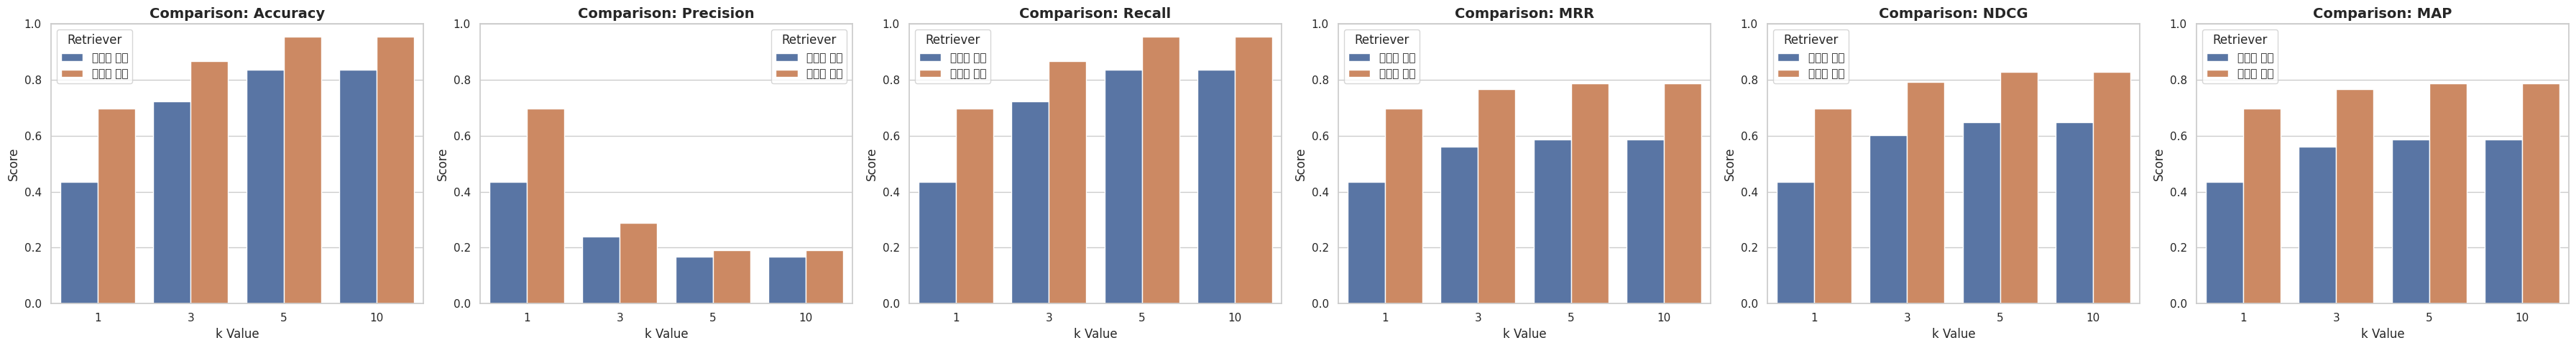

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def visualize_retriever_comparison(results_list, names):
    """
    여러 리트리버의 평가 결과를 시각화하여 비교하는 함수

    Args:
        results_list: evaluate_retriever 함수가 반환한 avg_metrics 딕셔너리 리스트
        names: 각 결과에 매칭되는 리트리버 이름 리스트 (예: ['Base', 'Improved'])
    """
    # 1. 데이터 포맷 변환 (Plotting을 위해 Long-form 데이터프레임 생성)
    data = []
    for metrics, name in zip(results_list, names):
        for metric_name, value in metrics.items():
            # 'Accuracy@1' -> 'Accuracy', '1' 분리
            metric_type, k_val = metric_name.split('@')
            data.append({
                'Retriever': name,
                'Metric': metric_type,
                'k': int(k_val),
                'Value': value
            })

    df_plot = pd.DataFrame(data)

    # 2. 시각화 설정
    sns.set_theme(style="whitegrid")
    metrics_to_show = df_plot['Metric'].unique()

    # 지표 개수에 따라 서브플롯 생성
    fig, axes = plt.subplots(1, len(metrics_to_show), figsize=(6 * len(metrics_to_show), 5))
    if len(metrics_to_show) == 1: axes = [axes]

    for ax, metric in zip(axes, metrics_to_show):
        subset = df_plot[df_plot['Metric'] == metric]
        sns.barplot(data=subset, x='k', y='Value', hue='Retriever', ax=ax)
        ax.set_title(f'Comparison: {metric}', fontsize=14, fontweight='bold')
        ax.set_ylim(0, 1.0) # 지표는 보통 0~1 사이
        ax.set_xlabel('k Value')
        ax.set_ylabel('Score')
        ax.legend(title='Retriever')

    plt.tight_layout()
    plt.show()

visualize_retriever_comparison([n_metrics, p_metrics], ["전처리 이전", "전처리 이후"])